## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Introducción al Aprendizaje Automático
**Actividad 4.** Modelos basados en distancias

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

## Etapa 1: Preprocesamiento y Análisis Exploratorio

1. Cargar y limpiar el dataset
2. Construir la tabla RFM (Recencia, Frecuencia, Monto) por cliente
3. Explorar visualmente los datos
4. Manejar los valores extremos (outliers)
5. Normalizar los datos para que todos estén en la misma escala

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
# Cargamos el dataset
df = pd.read_excel('Online Retail.xlsx')

print('Filas y columnas del dataset:', df.shape)
print('\nPrimeras 5 filas:')
df.head()

Filas y columnas del dataset: (541909, 8)

Primeras 5 filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Revisamos cuántos valores vacíos hay en cada columna
print('Valores nulos por columna:')
print(df.isnull().sum())

print('\nTipo de dato de cada columna:')
print(df.dtypes)

Valores nulos por columna:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Tipo de dato de cada columna:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


## Limpieza de datos

Vamos a eliminar los registros que no sirven para nuestro análisis:
- Filas sin CustomerID (no podemos identificar al cliente)
- Transacciones con cantidades negativas (devoluciones o errores)
- Precios iguales a cero
- Facturas canceladas (empiezan con la letra 'C')

In [4]:
# Guardamos el total de filas antes de limpiar, para ver cuánto eliminamos
total_antes = len(df)
print(f'Filas antes de limpiar: {total_antes:,}')

Filas antes de limpiar: 541,909


In [5]:
# Eliminamos filas sin CustomerID
df = df[df['CustomerID'].notna()]
print(f'Después de eliminar sin CustomerID: {len(df):,} filas')

Después de eliminar sin CustomerID: 406,829 filas


In [6]:
# Eliminamos cantidades negativas o cero
# Las cantidades negativas suelen ser devoluciones
df = df[df['Quantity'] > 0]
print(f'Después de eliminar cantidades negativas: {len(df):,} filas')

Después de eliminar cantidades negativas: 397,924 filas


In [7]:
# Eliminamos precios iguales a cero
df = df[df['UnitPrice'] > 0]
print(f'Después de eliminar precios cero: {len(df):,} filas')

Después de eliminar precios cero: 397,884 filas


In [8]:
# Eliminamos facturas canceladas
# Las facturas que empiezan con 'C' son cancelaciones
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Después de eliminar facturas canceladas: {len(df):,} filas')

Después de eliminar facturas canceladas: 397,884 filas


In [9]:
# Resumen de la limpieza
total_despues = len(df)
filas_eliminadas = total_antes - total_despues
porcentaje = (filas_eliminadas / total_antes) * 100

print('=== Resumen de limpieza ===')
print(f'Filas originales: {total_antes:,}')
print(f'Filas eliminadas: {filas_eliminadas:,} ({porcentaje:.1f}%)')
print(f'Filas que quedan: {total_despues:,}')

=== Resumen de limpieza ===
Filas originales: 541,909
Filas eliminadas: 144,025 (26.6%)
Filas que quedan: 397,884


---
## Construir la tabla RFM

RFM es una forma de resumir el comportamiento de compra de cada cliente en 3 números:

| Variable | Definición |
|----------|------------|
| Recencia (**R**) | Número de días desde la última compra del cliente hasta la fecha de referencia (menos días = mejor) |
| Frecuencia (**F**) | Número de transacciones (facturas únicas) del cliente (más veces = mejor) |
| Monto (**M**) | Gasto total acumulado del cliente (más dinero = mejor) |

In [10]:
# Primero calculamos el precio total de cada línea de compra
# Precio total = Cantidad * Precio unitario
df['precio_total'] = df['Quantity'] * df['UnitPrice']

# La fecha de referencia es el día siguiente al último registro del dataset
# Así calculamos correctamente cuántos días han pasado
fecha_referencia = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Fecha de referencia (último día + 1): {fecha_referencia.date()}')

Fecha de referencia (último día + 1): 2011-12-10


In [11]:
# Construimos la tabla RFM agrupando por cliente
# Cada fila será un cliente diferente
rfm = df.groupby('CustomerID').agg(
    recencia=('InvoiceDate', lambda x: (fecha_referencia - x.max()).days),
    frecuencia=('InvoiceNo', 'nunique'),  # 'nunique' cuenta facturas únicas
    monto=('precio_total', 'sum')
).reset_index()

print(f'Clientes únicos en la tabla RFM: {len(rfm):,}')
print('\nPrimeras 5 filas de la tabla RFM:')
rfm.head()

Clientes únicos en la tabla RFM: 4,338

Primeras 5 filas de la tabla RFM:


,CustomerID,recencia,frecuencia,monto
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [12]:
# Estadísticas básicas de la tabla RFM
print('Estadísticas descriptivas de las variables RFM:')
rfm[['recencia', 'frecuencia', 'monto']].describe().round(2)

Estadísticas descriptivas de las variables RFM:


,recencia,frecuencia,monto
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27
std,100.01,7.70,8989.23
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.00,5.00,1661.74
max,374.00,209.00,280206.02


---
## Exploración visual

Vamos a graficar cada variable para entender cómo están distribuidos los datos.

In [13]:
def graficar_distribucion(datos, columna, color, titulo):
    """
    Muestra un histograma y un boxplot juntos para ver cómo se distribuye una variable.
    - datos: el DataFrame con los datos
    - columna: el nombre de la columna a graficar
    - color: color de la gráfica
    - titulo: texto del título
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histograma: muestra cuántos clientes hay en cada rango de valores
    ax1.hist(datos[columna], bins=50, color=color, edgecolor='white')
    ax1.set_title(f'Histograma de {titulo}')
    ax1.set_xlabel(titulo)
    ax1.set_ylabel('Número de clientes')
    
    # Boxplot: muestra los outliers (puntos fuera de los bigotes)
    ax2.boxplot(datos[columna], vert=False, patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.6))
    ax2.set_title(f'Boxplot de {titulo}')
    ax2.set_xlabel(titulo)
    ax2.set_yticks([])
    
    plt.tight_layout()
    plt.show()

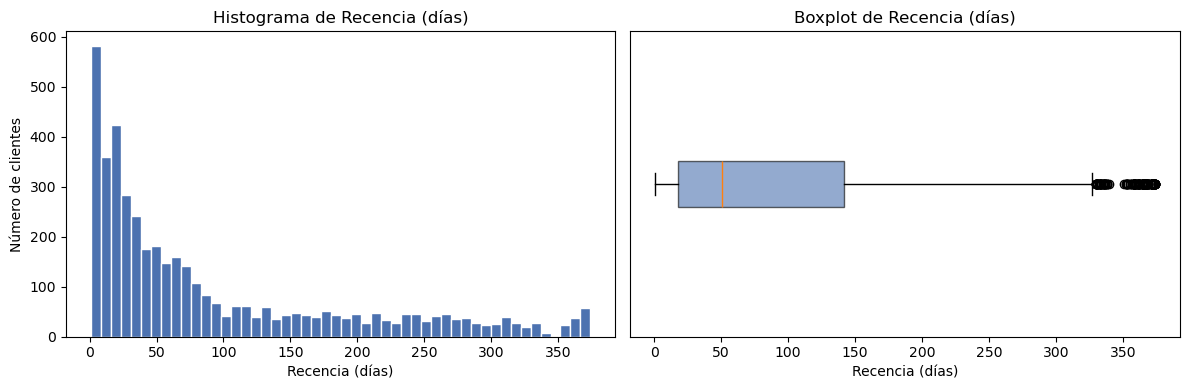

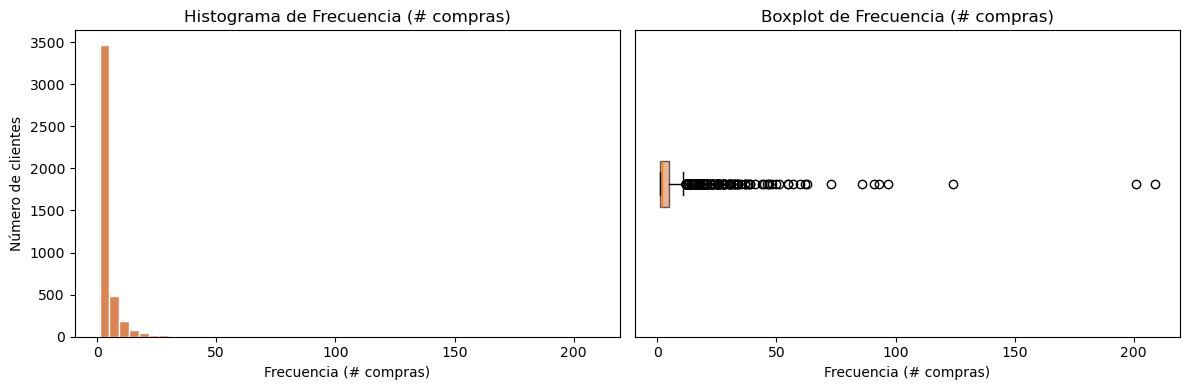

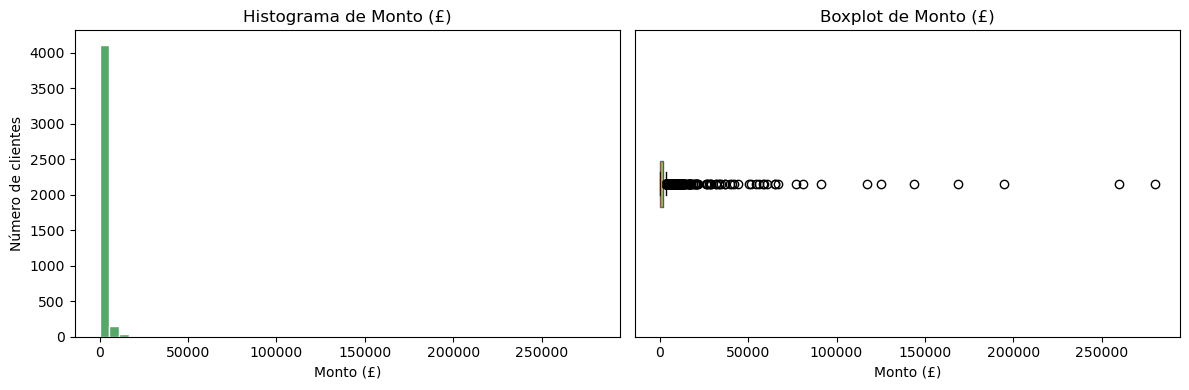

In [14]:
# Graficamos las tres variables RFM
graficar_distribucion(rfm, 'recencia',   '#4C72B0', 'Recencia (días)')
graficar_distribucion(rfm, 'frecuencia', '#DD8452', 'Frecuencia (# compras)')
graficar_distribucion(rfm, 'monto',      '#55A868', 'Monto (£)')

**¿Qué observamos?**  
- **Recencia**: Muchos clientes compraron recientemente, pero también hay clientes que llevan mucho tiempo sin comprar.  
- **Frecuencia y Monto**: La mayoría de los clientes compran pocas veces y gastan poco, pero hay algunos que compran muchísimo (posiblemente mayoristas). Estos son los **outliers** que vemos en los boxplots.

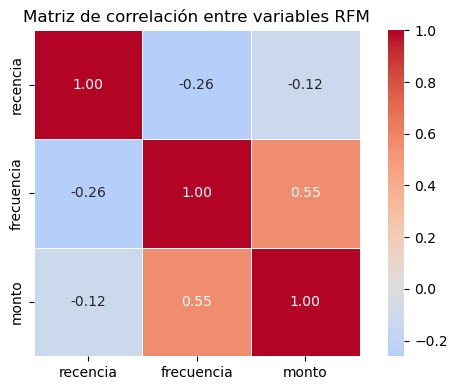

In [15]:
# Matriz de correlación
plt.figure(figsize=(6, 4))
correlaciones = rfm[['recencia', 'frecuencia', 'monto']].corr()
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de correlación entre variables RFM')
plt.tight_layout()
plt.show()

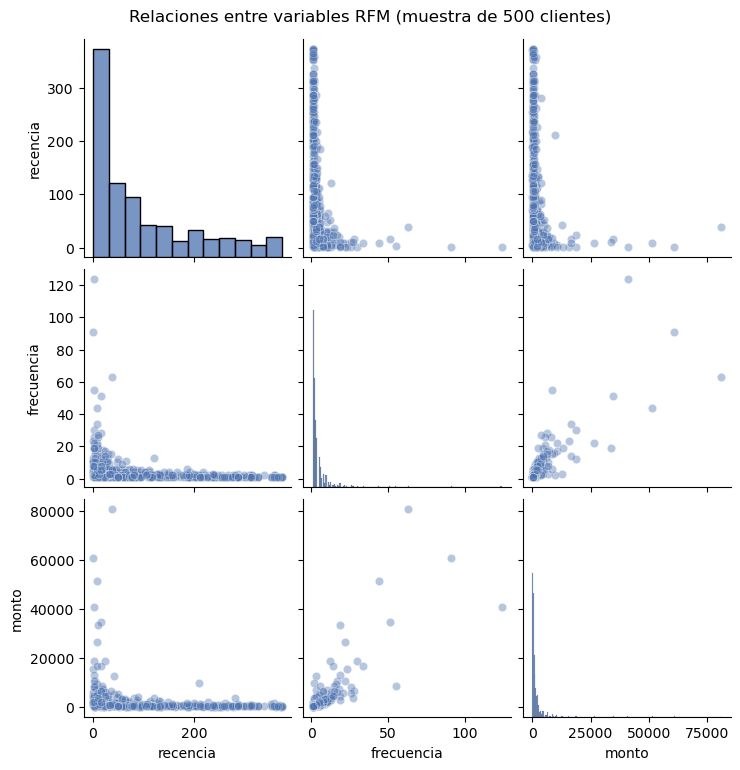

In [16]:
# Pairplot
# Muestra de 500 clientes para que no tarde tanto
muestra = rfm[['recencia', 'frecuencia', 'monto']].sample(500, random_state=42)

sns.pairplot(muestra, plot_kws={'alpha': 0.4, 'color': '#4C72B0'},
             diag_kws={'color': '#4C72B0'})
plt.suptitle('Relaciones entre variables RFM (muestra de 500 clientes)', y=1.02)
plt.show()

---
## Manejo de outliers
Usaremos **recorte por percentiles**: quitamos el 1% más bajo y el 1% más alto de cada variable.  
Así eliminamos los casos más extremos sin perder demasiados clientes.

In [17]:
def recortar_outliers(datos, columna, percentil_bajo=1, percentil_alto=99):
    """
    Elimina los valores más extremos de una columna.
    Solo conserva los valores que están entre el percentil_bajo y percentil_alto.
    """
    limite_bajo = datos[columna].quantile(percentil_bajo / 100)
    limite_alto = datos[columna].quantile(percentil_alto / 100)
    
    # Mostramos qué valores estamos usando como límites
    print(f'{columna}: límite inferior = {limite_bajo:.2f} | límite superior = {limite_alto:.2f}')
    
    # Filtramos y quedamos solo con los que están dentro del rango
    filtro = (datos[columna] >= limite_bajo) & (datos[columna] <= limite_alto)
    return datos[filtro]

In [18]:
print(f'Clientes antes del recorte: {len(rfm):,}')

rfm_limpio = rfm.copy()

# Aplicamos el recorte a las tres variables
rfm_limpio = recortar_outliers(rfm_limpio, 'recencia')
rfm_limpio = recortar_outliers(rfm_limpio, 'frecuencia')
rfm_limpio = recortar_outliers(rfm_limpio, 'monto')

print(f'\nClientes después del recorte: {len(rfm_limpio):,}')
print(f'Clientes eliminados: {len(rfm) - len(rfm_limpio):,}')

Clientes antes del recorte: 4,338
recencia: límite inferior = 1.00 | límite superior = 369.00
frecuencia: límite inferior = 1.00 | límite superior = 30.00
monto: límite inferior = 56.21 | límite superior = 13065.43

Clientes después del recorte: 4,169
Clientes eliminados: 169


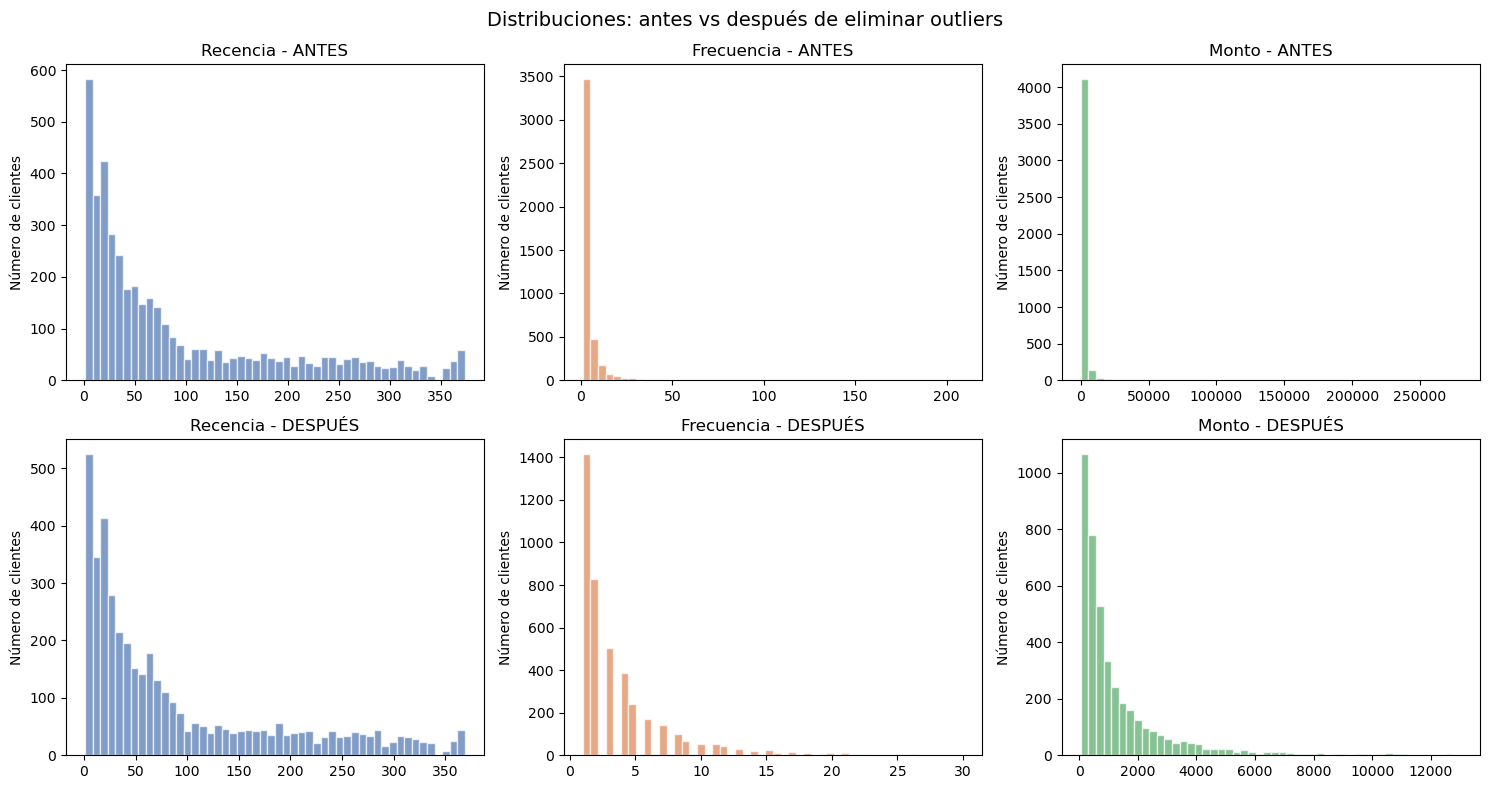

In [19]:
# Comparamos la distribución antes y después del recorte de outliers
# para confirmar que los valores extremos desaparecieron

variables = ['recencia', 'frecuencia', 'monto']
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribuciones: antes vs después de eliminar outliers', fontsize=14)

for i, (variable, color) in enumerate(zip(variables, colores)):
    # Fila de arriba: antes del recorte
    axes[0, i].hist(rfm[variable], bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{variable.capitalize()} - ANTES')
    axes[0, i].set_ylabel('Número de clientes')
    
    # Fila de abajo: después del recorte
    axes[1, i].hist(rfm_limpio[variable], bins=50, color=color, alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{variable.capitalize()} - DESPUÉS')
    axes[1, i].set_ylabel('Número de clientes')

plt.tight_layout()
plt.show()

---
## Normalización con StandardScaler

Si una variable tiene valores muy grandes (como el monto en libras) y otra tiene valores pequeños (como la recencia en días), la variable grande va a dominar el cálculo de distancias.

Usamos `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1.  
Así todas contribuyen por igual al análisis.  

Fórmula: `z = (valor - media) / desviación_estándar`

In [20]:
# Extraemos solo las 3 columnas RFM
X = rfm_limpio[['recencia', 'frecuencia', 'monto']].copy()

# Creamos el normalizador y lo aplicamos
normalizador = StandardScaler()
X_normalizado = normalizador.fit_transform(X)

# Convertimos a DataFrame para que sea más fácil de manejar
rfm_normalizado = pd.DataFrame(
    X_normalizado,
    columns=['recencia_norm', 'frecuencia_norm', 'monto_norm'],
    index=rfm_limpio.index
)

print('Primeras 5 filas de los datos normalizados:')
rfm_normalizado.head()

Primeras 5 filas de los datos normalizados:


,recencia_norm,frecuencia_norm,monto_norm
1,-0.920037,0.866661,1.724334
2,-0.164233,0.087414,0.274223
3,-0.744028,-0.691833,0.251318
4,2.268836,-0.691833,-0.569979
5,-0.568019,1.126410,0.683271


In [21]:
# Verificamos que la normalización fue correcta:
# La media debe estar cerca de 0 y la desviación estándar cerca de 1
print('Estadísticas después de normalizar (deben ser ~0 y ~1):')
rfm_normalizado.describe().round(4)

Estadísticas después de normalizar (deben ser ~0 y ~1):


,recencia_norm,frecuencia_norm,monto_norm
count,4169.0000,4169.0000,4169.0000
mean,0.0000,0.0000,-0.0000
std,1.0001,1.0001,1.0001
min,-0.9304,-0.6918,-0.7305
25%,-0.7544,-0.6918,-0.5833
50%,-0.4127,-0.4321,-0.3745
75%,0.4880,0.0874,0.1609
max,2.8797,6.8409,6.7552


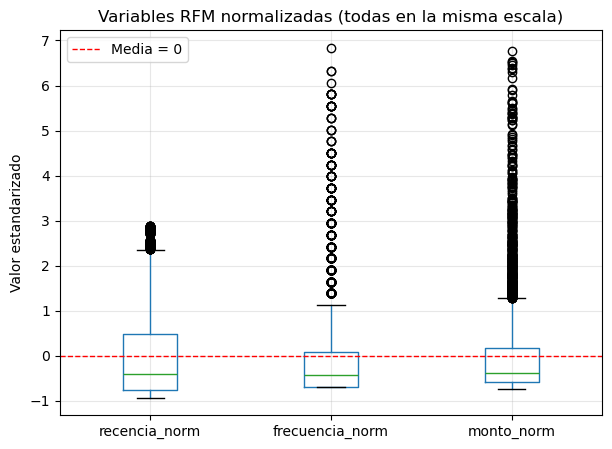

In [22]:
# Visualizamos los datos normalizados en un solo boxplot para confirmar
plt.figure(figsize=(7, 5))
rfm_normalizado.boxplot()
plt.axhline(0, color='red', linestyle='--', linewidth=1, label='Media = 0')
plt.title('Variables RFM normalizadas (todas en la misma escala)')
plt.ylabel('Valor estandarizado')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Guardamos los datos listos para la siguiente etapa
rfm_limpio.to_csv('rfm_limpio.csv', index=True) # datos originales sin outliers
rfm_normalizado.to_csv('rfm_normalizado.csv', index=True) # datos listos para clustering

print(f'\nTotal de clientes listos para la Etapa 2: {len(rfm_normalizado):,}')


Total de clientes listos para la Etapa 2: 4,169


---

## Etapa 2: Análisis exploratorio con Clustering Jerárquico

En esta etapa vamos a explorar la estructura natural de los clientes usando el agrupamiento jerárquico.  
Este método construye un árbol (llamado **dendrograma**) que muestra cómo se van uniendo los clientes en grupos.

Pasos:
1. Cargar los datos normalizados de la Etapa 1
2. Calcular la matriz de distancias euclidianas
3. Construir dendrogramas con dos criterios de enlace: **Ward** y **Complete**
4. Identificar el número de clusters
5. Cortar el dendrograma y visualizar los grupos

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform

# PCA: para reducir las 3 variables RFM a 2 dimensiones y poder graficarlas
from sklearn.decomposition import PCA

In [25]:
# Cargamos los archivos guardados en la Etapa 1
rfm_limpio     = pd.read_csv('rfm_limpio.csv', index_col=0)
rfm_normalizado = pd.read_csv('rfm_normalizado.csv', index_col=0)

print(f'Clientes cargados: {len(rfm_normalizado):,}')
print('\nPrimeras 5 filas de datos normalizados:')
rfm_normalizado.head()

Clientes cargados: 4,169

Primeras 5 filas de datos normalizados:


,recencia_norm,frecuencia_norm,monto_norm
1,-0.920037,0.866661,1.724334
2,-0.164233,0.087414,0.274223
3,-0.744028,-0.691833,0.251318
4,2.268836,-0.691833,-0.569979
5,-0.568019,1.126410,0.683271


---
## Calcular la matriz de distancias euclidianas

Antes de agrupar, necesitamos saber qué tan "lejos" está cada cliente de los demás.  
Usamos la **distancia euclidiana**: la distancia en línea recta entre dos puntos en el espacio de 3 dimensiones (R, F, M).

Como el dataset tiene muchos clientes, trabajaremos con una **muestra de 300** para que el dendrograma sea legible y el cálculo no tarde demasiado.  
*(Esto es lo recomendado para el clustering jerárquico con datasets grandes, tal como lo vimos en clase: n < 10000)*

In [26]:
# Tomamos una muestra aleatoria de 300 clientes
np.random.seed(42)
muestra = rfm_normalizado.sample(300, random_state=42)
muestra_rfm = rfm_limpio.loc[muestra.index]  # mismos clientes en datos originales

print(f'Clientes en la muestra: {len(muestra)}')

# Convertimos a numpy array (matriz de números)
X = muestra.values

# Calculamos la distancia euclidiana entre cada par de clientes
# pdist calcula todas las distancias de forma eficiente
distancias = pdist(X, metric='euclidean')

# squareform la convierte en una tabla cuadrada (cliente vs cliente)
matriz_dist = squareform(distancias)

print(f'\nTamaño de la matriz de distancias: {matriz_dist.shape}')
print(f'(Es {matriz_dist.shape[0]} x {matriz_dist.shape[1]}: un valor por cada par de clientes)')

Clientes en la muestra: 300

Tamaño de la matriz de distancias: (300, 300)
(Es 300 x 300: un valor por cada par de clientes)


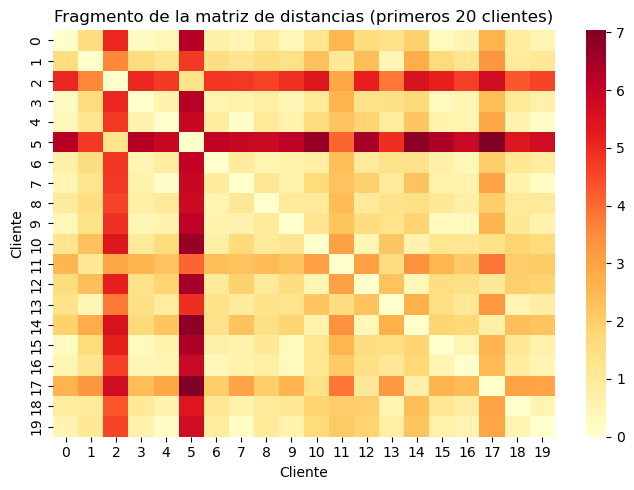

Distancia mínima entre dos clientes: 0.0096
Distancia máxima entre dos clientes: 7.7138


In [27]:
# Visualizamos una pequeña parte de la matriz de distancias
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_dist[:20, :20],  # solo los primeros 20 x 20 clientes
    cmap='YlOrRd',
    annot=False
)
plt.title('Fragmento de la matriz de distancias (primeros 20 clientes)')
plt.xlabel('Cliente')
plt.ylabel('Cliente')
plt.tight_layout()
plt.show()

print(f'Distancia mínima entre dos clientes: {distancias.min():.4f}')
print(f'Distancia máxima entre dos clientes: {distancias.max():.4f}')

**¿Qué observamos?**  
La diagonal es siempre **0** (un cliente está a distancia 0 de sí mismo).  
Los colores más oscuros indican clientes con comportamientos de compra muy diferentes entre sí.

---
## Construir dendrogramas

Cuando el algoritmo une dos grupos, necesita decidir **cómo medir la distancia entre grupos**.  
Hay distintas formas de hacerlo:

| Criterio | ¿Cómo mide la distancia entre dos grupos? | Resultado típico |
|----------|------------------------------------------|------------------|
| **Ward** | Minimiza el aumento de varianza al unir | Grupos esféricos y similares. **El más recomendado** |
| **Complete** | Usa la distancia máxima entre todos los pares | Grupos compactos, sensible a outliers |

In [28]:
# Calculamos el árbol de fusiones para cada criterio de enlace
# linkage() aplica el algoritmo aglomerativo y devuelve el historial de fusiones
enlace_ward     = linkage(X, method='ward')
enlace_complete = linkage(X, method='complete')

print('Árboles calculados:')
print(f'  Ward     → {len(enlace_ward)} fusiones registradas')
print(f'  Complete → {len(enlace_complete)} fusiones registradas')
print('(Siempre hay n-1 fusiones para n puntos)')

Árboles calculados:
  Ward     → 299 fusiones registradas
  Complete → 299 fusiones registradas
(Siempre hay n-1 fusiones para n puntos)


In [29]:
def graficar_dendrograma(enlace, titulo, color):
    """
    Dibuja un dendrograma a partir del árbol de fusiones.
    - El eje Y muestra a qué distancia se unieron dos grupos.
    - Los 'saltos' grandes en el eje Y indican fronteras naturales entre clusters.
    """
    plt.figure(figsize=(14, 6))
    
    dendrogram(
        enlace,
        truncate_mode='lastp',  # Muestra solo las últimas 30 fusiones
        p=30,                   # para que sea legible
        leaf_rotation=90,
        leaf_font_size=9,
        above_threshold_color=color
    )
    
    plt.title(titulo, fontsize=14)
    plt.xlabel('Grupos de clientes (número entre paréntesis = cuántos clientes hay en ese grupo)')
    plt.ylabel('Distancia de fusión')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

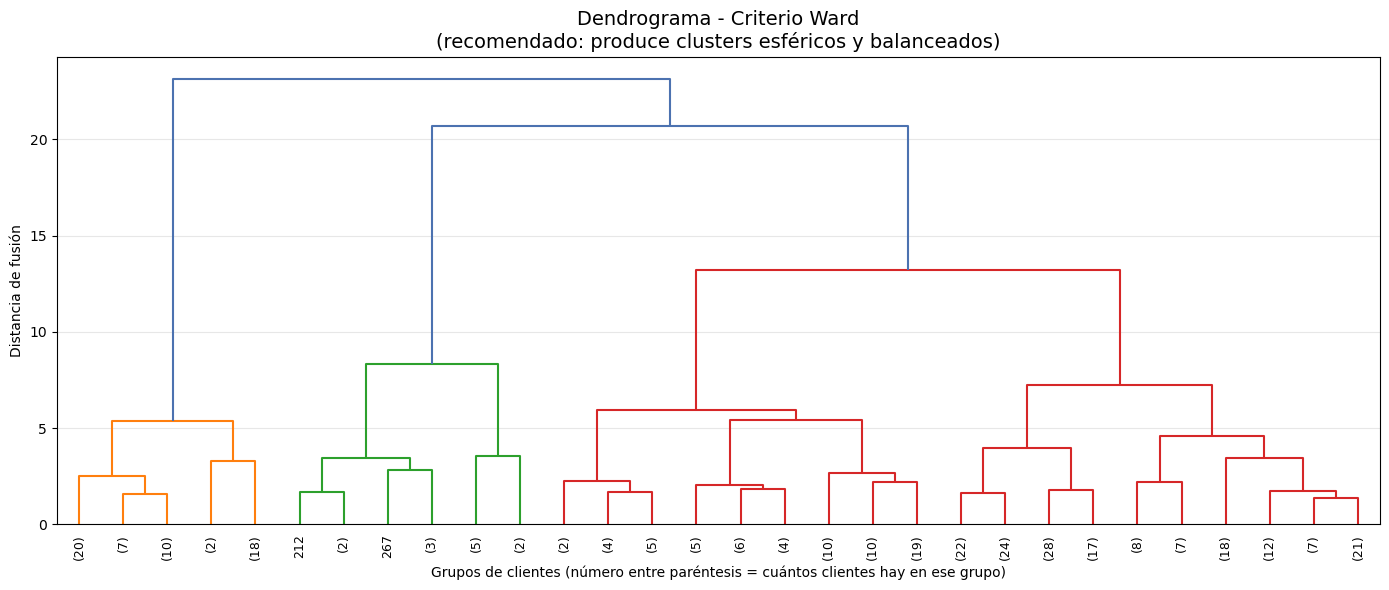

In [30]:
# Dendrograma con criterio Ward
graficar_dendrograma(
    enlace_ward,
    'Dendrograma - Criterio Ward\n(recomendado: produce clusters esféricos y balanceados)',
    '#4C72B0'
)

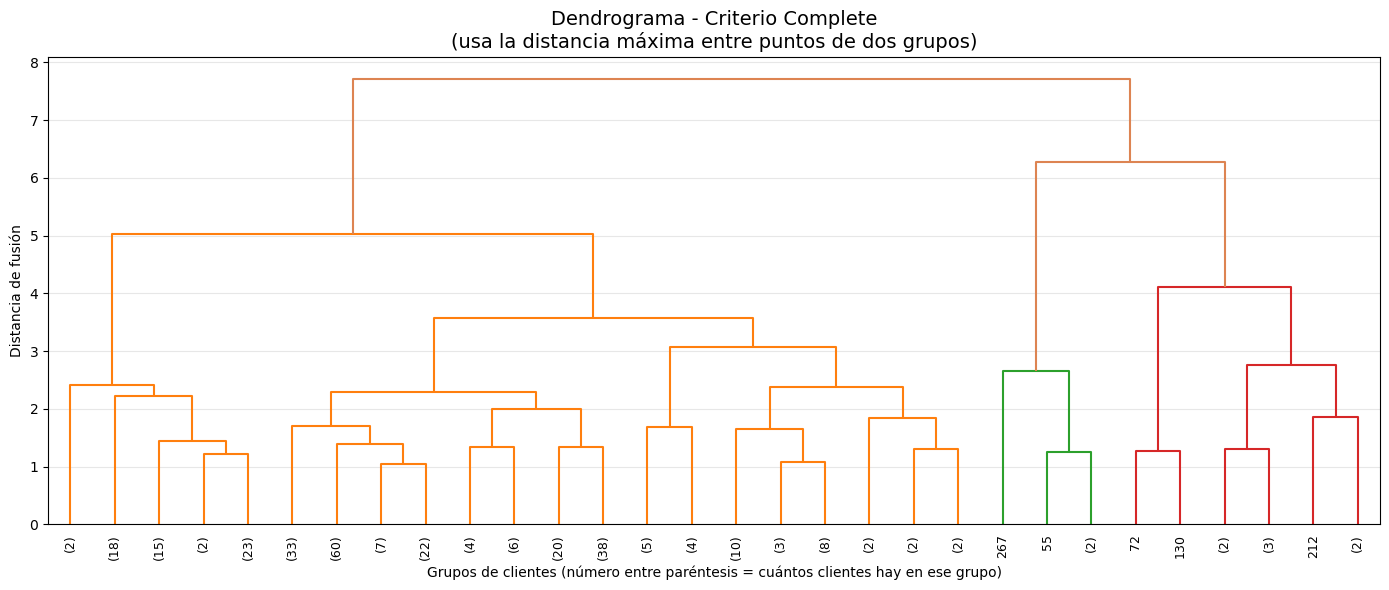

In [31]:
# Dendrograma con criterio Complete
graficar_dendrograma(
    enlace_complete,
    'Dendrograma - Criterio Complete\n(usa la distancia máxima entre puntos de dos grupos)',
    '#DD8452'
)

---
## Analizar la estructura jerárquica

Buscamos el salto más grande en el eje Y del dendrograma.  
Un salto grande significa que estamos uniendo dos grupos que son muy diferentes entre sí.

In [32]:
def analizar_saltos(enlace, nombre_criterio, top_n=10):
    """
    Calcula los saltos entre alturas de fusión consecutivas.
    Un salto grande = hay una separación natural ahí = buen lugar para cortar.
    """
    # La columna 2 del árbol de fusiones contiene las alturas (distancias)
    alturas = enlace[:, 2]
    
    # Calculamos la diferencia entre fusiones consecutivas (de mayor a menor)
    alturas_ordenadas = np.sort(alturas)[::-1]
    saltos = np.diff(alturas_ordenadas)  # diferencia entre valores consecutivos
    
    print(f'\n=== Criterio {nombre_criterio} ===')
    print(f'Las {top_n} alturas de fusión más grandes:')
    for i, h in enumerate(alturas_ordenadas[:top_n]):
        salto = abs(saltos[i]) if i < len(saltos) else 0
        print(f'  Fusión {i+1:2d}: altura = {h:.4f}  |  salto respecto a la siguiente = {salto:.4f}')
    
    return alturas_ordenadas, saltos

alturas_ward, saltos_ward = analizar_saltos(enlace_ward, 'Ward')
alturas_complete, saltos_complete = analizar_saltos(enlace_complete, 'Complete')


=== Criterio Ward ===
Las 10 alturas de fusión más grandes:
  Fusión  1: altura = 23.1454  |  salto respecto a la siguiente = 2.4574
  Fusión  2: altura = 20.6880  |  salto respecto a la siguiente = 7.4486
  Fusión  3: altura = 13.2395  |  salto respecto a la siguiente = 4.9218
  Fusión  4: altura = 8.3176  |  salto respecto a la siguiente = 1.0766
  Fusión  5: altura = 7.2411  |  salto respecto a la siguiente = 1.3020
  Fusión  6: altura = 5.9391  |  salto respecto a la siguiente = 0.5206
  Fusión  7: altura = 5.4185  |  salto respecto a la siguiente = 0.0409
  Fusión  8: altura = 5.3776  |  salto respecto a la siguiente = 0.7769
  Fusión  9: altura = 4.6007  |  salto respecto a la siguiente = 0.6242
  Fusión 10: altura = 3.9765  |  salto respecto a la siguiente = 0.4086

=== Criterio Complete ===
Las 10 alturas de fusión más grandes:
  Fusión  1: altura = 7.7138  |  salto respecto a la siguiente = 1.4398
  Fusión  2: altura = 6.2741  |  salto respecto a la siguiente = 1.2449
  Fusió

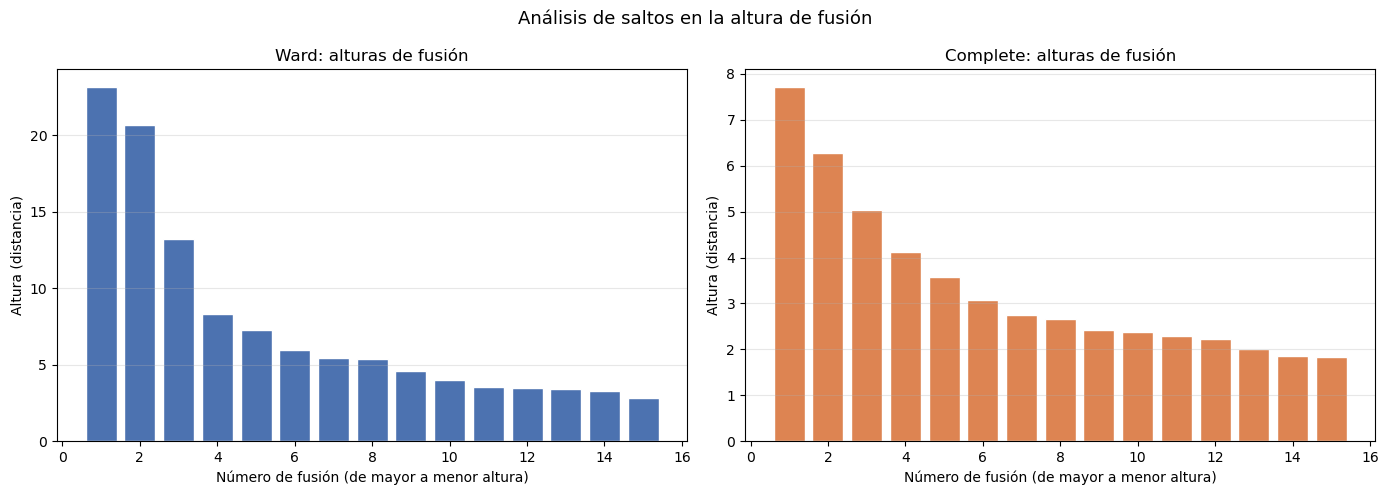

Interpretación: el "codo" en la curva indica cuántos clusters tiene sentido elegir.
Si hay un salto grande entre la barra 3 y 4, conviene elegir 3 clusters.


In [33]:
# Graficamos los saltos para Ward para identificar visualmente el corte óptimo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis de saltos en la altura de fusión', fontsize=13)

# Ward
n_mostrar = 15  # mostramos las últimas 15 fusiones (las más importantes)
ax1.bar(range(1, n_mostrar + 1), alturas_ward[:n_mostrar],
        color='#4C72B0', edgecolor='white')
ax1.set_title('Ward: alturas de fusión')
ax1.set_xlabel('Número de fusión (de mayor a menor altura)')
ax1.set_ylabel('Altura (distancia)')
ax1.grid(axis='y', alpha=0.3)

# Complete
ax2.bar(range(1, n_mostrar + 1), alturas_complete[:n_mostrar],
        color='#DD8452', edgecolor='white')
ax2.set_title('Complete: alturas de fusión')
ax2.set_xlabel('Número de fusión (de mayor a menor altura)')
ax2.set_ylabel('Altura (distancia)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Interpretación: el "codo" en la curva indica cuántos clusters tiene sentido elegir.')
print('Si hay un salto grande entre la barra 3 y 4, conviene elegir 3 clusters.')

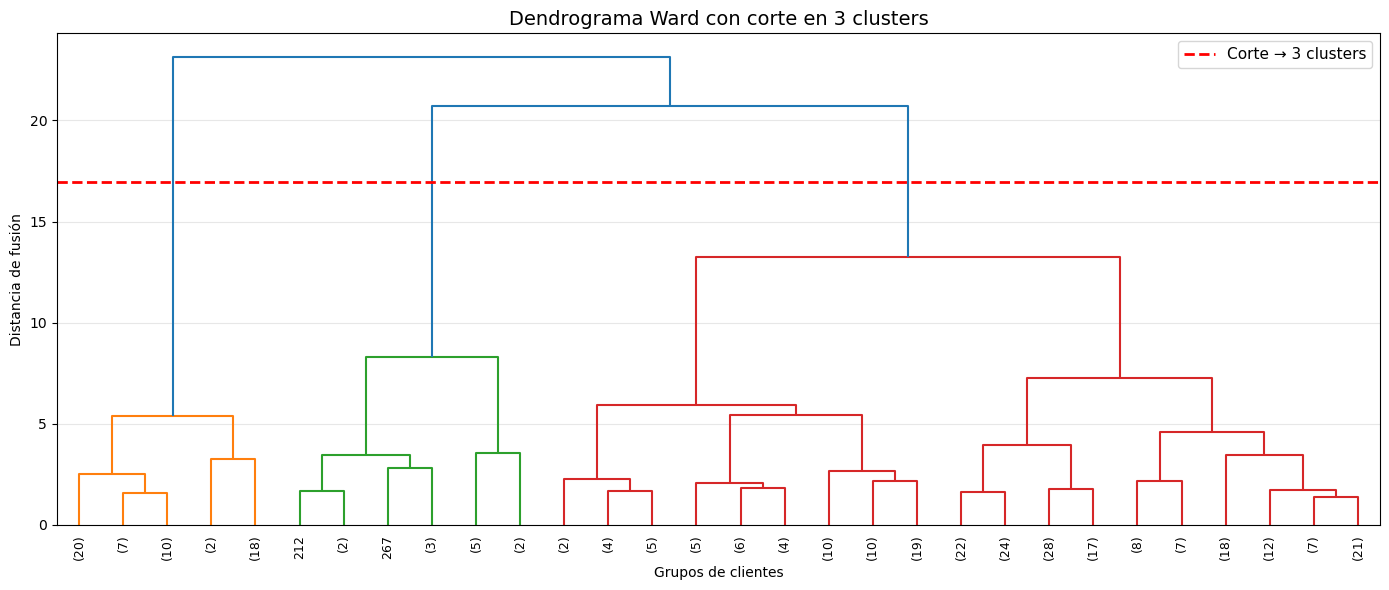

Altura de corte seleccionada: 16.9637


In [34]:
# Dendrograma Ward con una línea de corte para visualizar los clusters elegidos
# Proponemos 3 clusters basándonos en el análisis de saltos

N_CLUSTERS = 3  # número tentativo propuesto

# El umbral de corte es el punto medio entre la altura de la fusión N_CLUSTERS
# y la siguiente fusión
alturas_ward_asc = np.sort(enlace_ward[:, 2])  # ordenadas de menor a mayor
altura_corte = (alturas_ward_asc[-(N_CLUSTERS)] + alturas_ward_asc[-(N_CLUSTERS - 1)]) / 2

plt.figure(figsize=(14, 6))
dendrogram(
    enlace_ward,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=altura_corte
)
# Línea horizontal que muestra dónde estamos cortando
plt.axhline(y=altura_corte, color='red', linestyle='--', linewidth=2,
            label=f'Corte → {N_CLUSTERS} clusters')
plt.title(f'Dendrograma Ward con corte en {N_CLUSTERS} clusters', fontsize=14)
plt.xlabel('Grupos de clientes')
plt.ylabel('Distancia de fusión')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Altura de corte seleccionada: {altura_corte:.4f}')

---
## Cortar el dendrograma y asignar clusters

Ahora cortamos el árbol para obtener el número de grupos que elegimos.  
Usamos el criterio **Ward** ya que, según la teoría, produce los clusters más balanceados.

In [35]:
# Cortamos el dendrograma para obtener N_CLUSTERS grupos
# fcluster asigna a cada cliente un número de cluster (1, 2, 3...)
etiquetas = fcluster(enlace_ward, t=N_CLUSTERS, criterion='maxclust')

# Agregamos las etiquetas a la tabla de clientes
muestra_rfm = muestra_rfm.copy()
muestra_rfm['cluster'] = etiquetas

# Contamos cuántos clientes hay en cada cluster
conteo = muestra_rfm['cluster'].value_counts().sort_index()
print('Clientes por cluster:')
for cluster_id, cantidad in conteo.items():
    print(f'  Cluster {cluster_id}: {cantidad} clientes ({cantidad/len(muestra_rfm)*100:.1f}%)')

Clientes por cluster:
  Cluster 1: 57 clientes (19.0%)
  Cluster 2: 14 clientes (4.7%)
  Cluster 3: 229 clientes (76.3%)


In [36]:
# Estadísticas de cada cluster en los valores originales (no normalizados)
print('Perfil promedio de cada cluster (valores originales):')
perfil = muestra_rfm.groupby('cluster')[['recencia', 'frecuencia', 'monto']].mean().round(2)
perfil

Perfil promedio de cada cluster (valores originales):


,recencia,frecuencia,monto
cluster,,,
1,265.14,1.46,529.09
2,23.36,13.07,6559.67
3,48.12,3.30,1159.00


---
## Visualizar los clusters en 2D con PCA

Tenemos 3 variables (R, F, M), pero solo podemos graficar 2 dimensiones.  
Usamos **PCA (Análisis de Componentes Principales)** para comprimir las 3 variables en 2 sin perder demasiada información.

In [37]:
# Reducimos las 3 variables RFM a 2 dimensiones con PCA
pca = PCA(n_components=2, random_state=42)
coordenadas_2d = pca.fit_transform(muestra.values)

varianza_explicada = pca.explained_variance_ratio_
print(f'Varianza explicada por componente 1: {varianza_explicada[0]*100:.1f}%')
print(f'Varianza explicada por componente 2: {varianza_explicada[1]*100:.1f}%')
print(f'Total explicado con 2 componentes  : {sum(varianza_explicada)*100:.1f}%')

Varianza explicada por componente 1: 61.6%
Varianza explicada por componente 2: 28.4%
Total explicado con 2 componentes  : 90.0%


In [38]:
def graficar_clusters_2d(coordenadas, etiquetas, titulo, nombre_x, nombre_y):
    """
    Scatter plot donde cada punto es un cliente, coloreado según su cluster.
    """
    colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
    marcadores = ['o', 's', '^', 'D', 'v']
    
    plt.figure(figsize=(9, 6))
    
    clusters_unicos = sorted(set(etiquetas))
    for i, c in enumerate(clusters_unicos):
        mascara = etiquetas == c
        plt.scatter(
            coordenadas[mascara, 0],
            coordenadas[mascara, 1],
            c=colores[i % len(colores)],
            marker=marcadores[i % len(marcadores)],
            label=f'Cluster {c} (n={mascara.sum()})',
            alpha=0.7,
            s=60,
            edgecolors='white',
            linewidth=0.5
        )
    
    plt.title(titulo, fontsize=13)
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

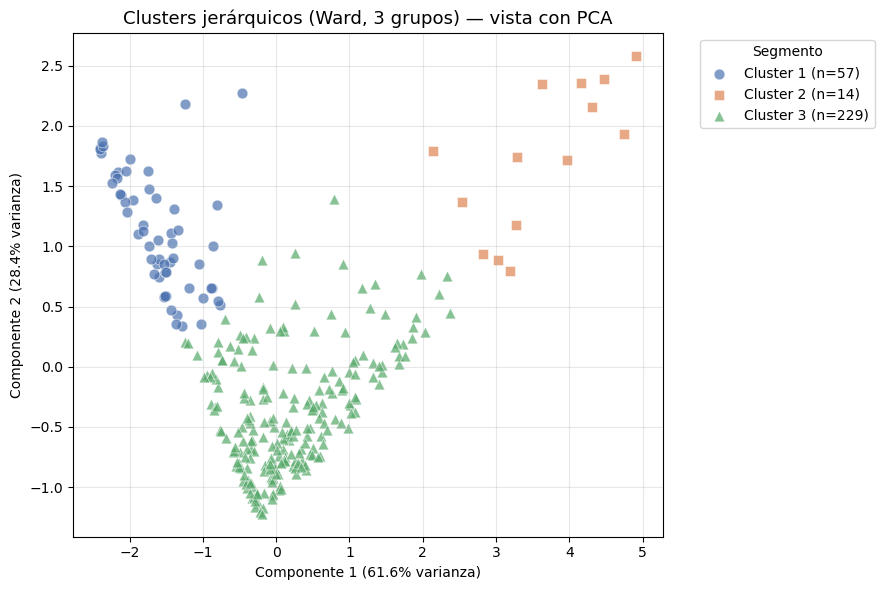

In [39]:
# Scatter plot usando las 2 componentes PCA
graficar_clusters_2d(
    coordenadas_2d,
    etiquetas,
    titulo=f'Clusters jerárquicos (Ward, {N_CLUSTERS} grupos) — vista con PCA',
    nombre_x=f'Componente 1 ({varianza_explicada[0]*100:.1f}% varianza)',
    nombre_y=f'Componente 2 ({varianza_explicada[1]*100:.1f}% varianza)'
)

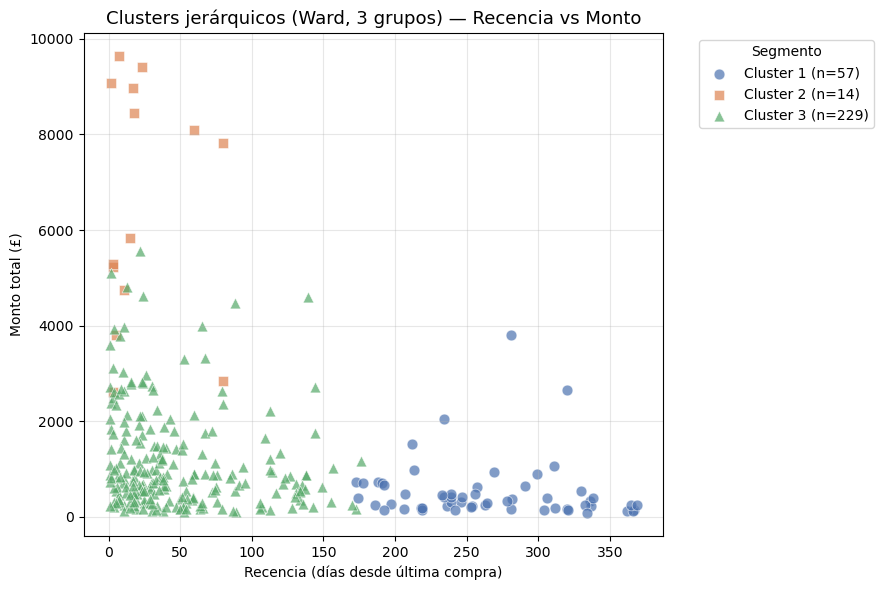

In [40]:
# También podemos visualizar directamente con dos variables RFM (sin PCA)
# Usamos Recencia vs Monto porque suelen ser las más informativas
valores_rfm = muestra_rfm[['recencia', 'monto']].values

graficar_clusters_2d(
    valores_rfm,
    etiquetas,
    titulo=f'Clusters jerárquicos (Ward, {N_CLUSTERS} grupos) — Recencia vs Monto',
    nombre_x='Recencia (días desde última compra)',
    nombre_y='Monto total (£)'
)

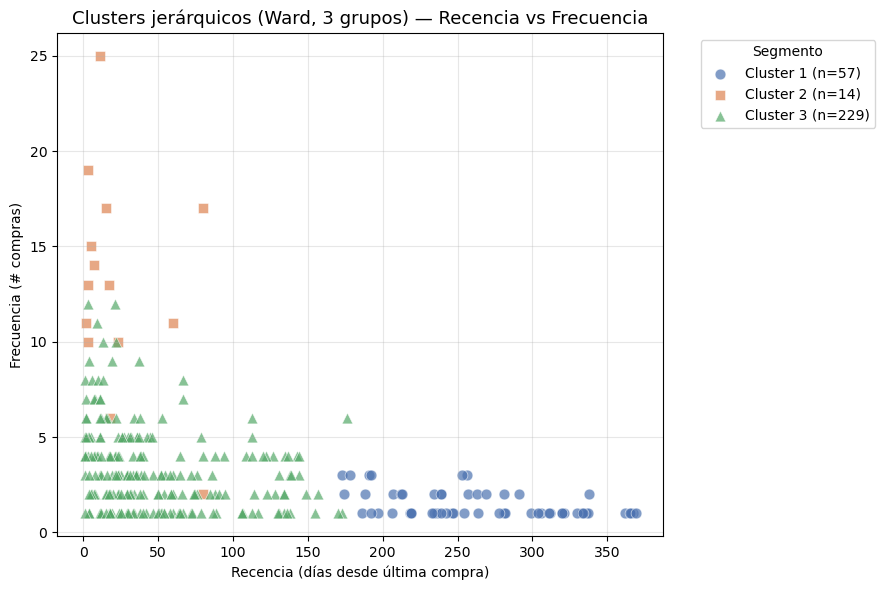

In [41]:
# Recencia vs Frecuencia
valores_rfm2 = muestra_rfm[['recencia', 'frecuencia']].values

graficar_clusters_2d(
    valores_rfm2,
    etiquetas,
    titulo=f'Clusters jerárquicos (Ward, {N_CLUSTERS} grupos) — Recencia vs Frecuencia',
    nombre_x='Recencia (días desde última compra)',
    nombre_y='Frecuencia (# compras)'
)

---
## Caracterización de los segmentos

Vamos a darle nombre a cada cluster según su comportamiento de compra.

In [42]:
# Perfil completo de cada cluster con estadísticas
print('=== Perfil detallado por cluster ===')
print()

for cluster_id in sorted(muestra_rfm['cluster'].unique()):
    grupo = muestra_rfm[muestra_rfm['cluster'] == cluster_id]
    print(f'--- Cluster {cluster_id} ({len(grupo)} clientes) ---')
    print(f'  Recencia   : media={grupo["recencia"].mean():.0f} días   | mediana={grupo["recencia"].median():.0f} días')
    print(f'  Frecuencia : media={grupo["frecuencia"].mean():.1f} compras | mediana={grupo["frecuencia"].median():.0f} compras')
    print(f'  Monto      : media=£{grupo["monto"].mean():.0f}         | mediana=£{grupo["monto"].median():.0f}')
    print()

=== Perfil detallado por cluster ===

--- Cluster 1 (57 clientes) ---
  Recencia   : media=265 días   | mediana=256 días
  Frecuencia : media=1.5 compras | mediana=1 compras
  Monto      : media=£529         | mediana=£329

--- Cluster 2 (14 clientes) ---
  Recencia   : media=23 días   | mediana=13 días
  Frecuencia : media=13.1 compras | mediana=13 compras
  Monto      : media=£6560         | mediana=£6833

--- Cluster 3 (229 clientes) ---
  Recencia   : media=48 días   | mediana=33 días
  Frecuencia : media=3.3 compras | mediana=3 compras
  Monto      : media=£1159         | mediana=£809



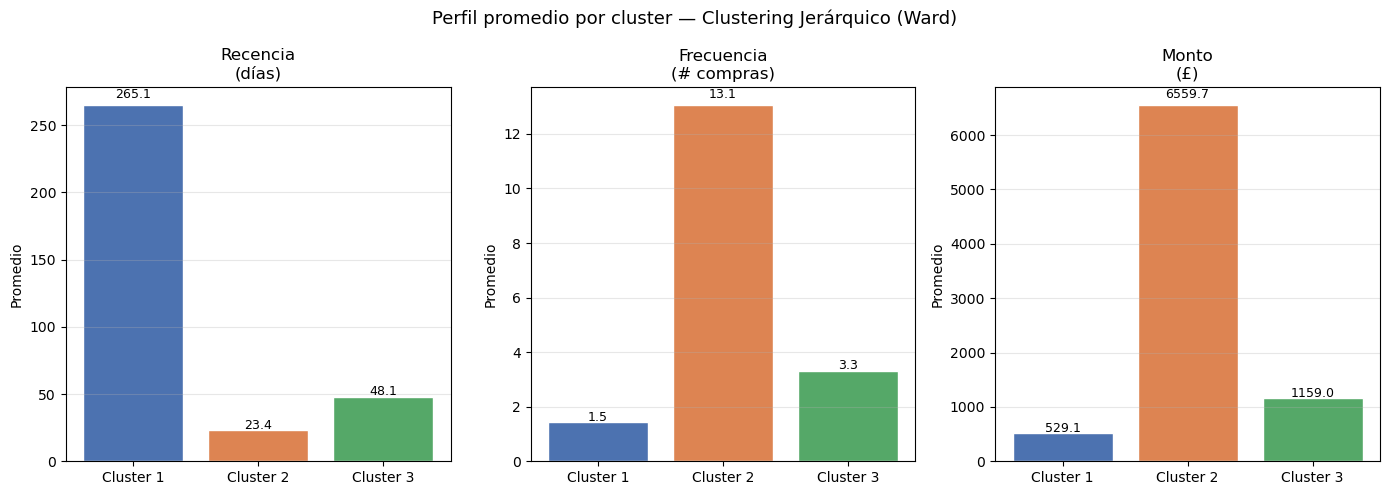

In [43]:
# Comparamos el perfil promedio de cada cluster
variables = ['recencia', 'frecuencia', 'monto']
etiquetas_var = ['Recencia\n(días)', 'Frecuencia\n(# compras)', 'Monto\n(£)']
colores_cluster = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Perfil promedio por cluster — Clustering Jerárquico (Ward)', fontsize=13)

for i, (var, etq) in enumerate(zip(variables, etiquetas_var)):
    promedios = [muestra_rfm[muestra_rfm['cluster'] == c][var].mean()
                 for c in sorted(muestra_rfm['cluster'].unique())]
    
    axes[i].bar(
        [f'Cluster {c}' for c in sorted(muestra_rfm['cluster'].unique())],
        promedios,
        color=colores_cluster,
        edgecolor='white'
    )
    axes[i].set_title(etq)
    axes[i].set_ylabel('Promedio')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Etiqueta con el valor encima de cada barra
    for j, v in enumerate(promedios):
        axes[i].text(j, v * 1.02, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Ventajas y limitaciones del clustering jerárquico

### Ventajas para este problema

1. **No necesitamos saber K de antemano.**  
   El dendrograma nos muestra la estructura y podemos elegir el número de clusters después de verlo.

2. **El dendrograma es muy interpretable.**  
   Se puede ver claramente qué clientes son similares y a qué distancia se unen.

3. **El criterio Ward produjo clusters bien definidos.**  
   Los grupos resultantes tienen perfiles RFM claramente diferenciados.

### Limitaciones para este problema

1. **No escala bien a datasets grandes.**  
   El dataset completo tiene ~4,300 clientes. El clustering jerárquico tiene complejidad O(n³),  
   por eso tuvimos que trabajar con una muestra de 300 clientes.

2. **Las fusiones son irreversibles.**  
   Una vez que dos clientes se unen, no se pueden separar. Si hay un error al inicio, se arrastra.

3. **Sensible a outliers.**  
   Por eso fue importante hacer el recorte de outliers en la Etapa 1 antes de aplicar este método.

4. **Solo usamos una muestra.**  
   Los clusters son representativos pero no abarcan a todos los clientes del dataset.

### Conclusión

El clustering jerárquico es una excelente herramienta para explorar la estructura de los datos.  
El dendrograma sugiere que **3 clusters** es una buena opción para este dataset.

In [44]:
# Guardamos las etiquetas de cluster de la muestra para referencia futura
muestra_rfm.to_csv('rfm_jerarquico.csv', index=True)

print(f'\nResumen final:')
print(f'  Método usado:       Clustering Jerárquico Aglomerativo')
print(f'  Criterio de enlace: Ward')
print(f'  Distancia:          Euclidiana')
print(f'  Clientes analizados: {len(muestra_rfm)}')
print(f'  Clusters propuestos: {N_CLUSTERS}')


Resumen final:
  Método usado:       Clustering Jerárquico Aglomerativo
  Criterio de enlace: Ward
  Distancia:          Euclidiana
  Clientes analizados: 300
  Clusters propuestos: 3


---

## Etapa 3: Segmentación con K-Medias (K-Means)

En la Etapa 2 usamos el clustering jerárquico para **explorar** la estructura de los datos con una muestra.  
Ahora usaremos **K-Medias** sobre el dataset completo para crear los segmentos finales.

K-Medias es mucho más eficiente y escala bien a miles de clientes.  
El algoritmo busca K grupos minimizando la distancia de cada cliente a su centroide (punto central del grupo).

Pasos:
1. Elegir el número óptimo de clusters K
2. Ejecutar K-Medias con ese K
3. Caracterizar y etiquetar cada segmento
4. Visualizar los resultados
5. Comparar con los resultados del clustering jerárquico

In [45]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [54]:
# Usamos los datos normalizados y limpios de la Etapa 1, rfm_limpio, rfm_normalizado, X
rfm_limpio      = pd.read_csv('rfm_limpio.csv', index_col=0)
rfm_normalizado = pd.read_csv('rfm_normalizado.csv', index_col=0)

# Array numpy para pasarlo a los algoritmos de sklearn
X = rfm_normalizado.values

print(f'Clientes disponibles para clustering: {len(rfm_limpio):,}')
print('Variables:', rfm_normalizado.columns.tolist())

Clientes disponibles para clustering: 4,169
Variables: ['recencia_norm', 'frecuencia_norm', 'monto_norm']


---
## Determinar el K óptimo

Usaremos dos métodos complementarios:
- **Método del codo:** grafica la inercia (suma de distancias al centroide) para cada K. El "codo" es donde agregar más clusters deja de aportar mucho.
- **Coeficiente de silueta:** mide qué tan bien separados están los clusters. Rango: [-1, 1]. **Más alto = mejor.**

In [55]:
# Probamos K desde 2 hasta 10 y guardamos inercia y silueta
rango_k    = range(2, 11)
inercias   = []
siluetas   = []

print('Calculando métricas para cada valor de K...')

for k in rango_k:
    modelo = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    etiquetas_k = modelo.fit_predict(X)

    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(X, etiquetas_k))
    print(f'  K={k}: inercia={modelo.inertia_:.1f} | silueta={siluetas[-1]:.4f}')

Calculando métricas para cada valor de K...
  K=2: inercia=7241.4 | silueta=0.5310
  K=3: inercia=4086.6 | silueta=0.5085
  K=4: inercia=2907.4 | silueta=0.4802
  K=5: inercia=2477.5 | silueta=0.4396
  K=6: inercia=2096.9 | silueta=0.4144
  K=7: inercia=1807.8 | silueta=0.4144
  K=8: inercia=1612.4 | silueta=0.3773
  K=9: inercia=1452.9 | silueta=0.3821
  K=10: inercia=1338.8 | silueta=0.3474


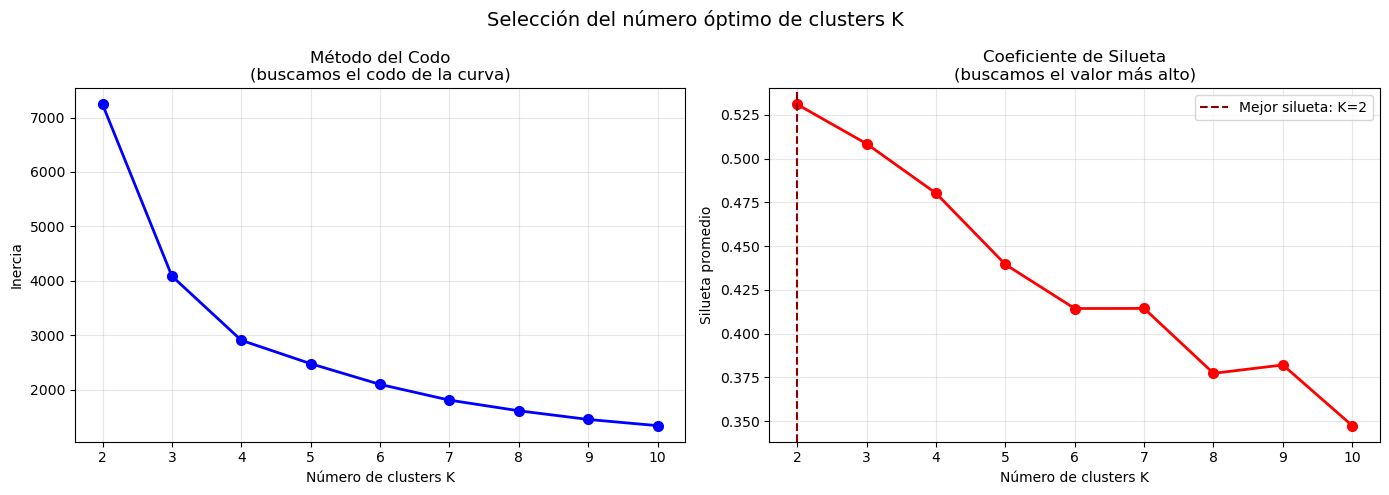

K con mayor coeficiente de silueta: 2


In [56]:
# Graficamos ambas métricas juntas para decidir el K óptimo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selección del número óptimo de clusters K', fontsize=14)

# Gráfica 1: Método del codo
ax1.plot(rango_k, inercias, 'bo-', linewidth=2, markersize=7)
ax1.set_title('Método del Codo\n(buscamos el codo de la curva)')
ax1.set_xlabel('Número de clusters K')
ax1.set_ylabel('Inercia')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(rango_k))

# Gráfica 2: Coeficiente de silueta
ax2.plot(rango_k, siluetas, 'ro-', linewidth=2, markersize=7)
ax2.set_title('Coeficiente de Silueta\n(buscamos el valor más alto)')
ax2.set_xlabel('Número de clusters K')
ax2.set_ylabel('Silueta promedio')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(rango_k))

# Marcamos el K que tiene la silueta más alta
mejor_k_silueta = list(rango_k)[siluetas.index(max(siluetas))]
ax2.axvline(mejor_k_silueta, color='darkred', linestyle='--',
            label=f'Mejor silueta: K={mejor_k_silueta}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'K con mayor coeficiente de silueta: {mejor_k_silueta}')

In [57]:
# Elegimos el K óptimo combinando ambas evidencias
# - El codo sugiere un punto donde la inercia deja de bajar mucho
# - La silueta confirma qué K produce clusters mejor separados
# La Etapa 2 (jerárquico) también sugirió 3 clusters

K_OPTIMO = 3

print(f'K seleccionado: {K_OPTIMO}')
print(f'Inercia    con K={K_OPTIMO}: {inercias[K_OPTIMO - 2]:.2f}')
print(f'Silueta    con K={K_OPTIMO}: {siluetas[K_OPTIMO - 2]:.4f}')

K seleccionado: 3
Inercia    con K=3: 4086.58
Silueta    con K=3: 0.5085


---
## Ejecutar K-Medias con el K seleccionado

In [58]:
# Entrenamos el modelo final con el K elegido
kmeans = KMeans(
    n_clusters=K_OPTIMO,
    init='k-means++',
    n_init=10,
    random_state=42
)

etiquetas = kmeans.fit_predict(X)

# Agregamos el cluster a la tabla con valores originales
rfm_final = rfm_limpio.copy()
rfm_final['cluster'] = etiquetas

print(f'Inercia final: {kmeans.inertia_:.2f}')
print(f'Silueta final: {silhouette_score(X, etiquetas):.4f}')

print('\nClientes por cluster:')
conteo = rfm_final['cluster'].value_counts().sort_index()
for c, n in conteo.items():
    print(f'  Cluster {c}: {n:,} clientes ({n/len(rfm_final)*100:.1f}%)')

Inercia final: 4086.58
Silueta final: 0.5085

Clientes por cluster:
  Cluster 0: 1,024 clientes (24.6%)
  Cluster 1: 2,696 clientes (64.7%)
  Cluster 2: 449 clientes (10.8%)


---
## Caracterizar los segmentos

In [59]:
# Calculamos el promedio de cada variable RFM por cluster
perfil = rfm_final.groupby('cluster')[['recencia', 'frecuencia', 'monto']].mean().round(2)

print('Perfil promedio por cluster (valores originales):')
perfil

Perfil promedio por cluster (valores originales):


,recencia,frecuencia,monto
cluster,,,
0,240.97,1.51,448.13
1,45.32,3.07,1014.23
2,21.98,12.15,5163.57


In [60]:
print('=== Perfil detallado por cluster ===')
for c in sorted(rfm_final['cluster'].unique()):
    g = rfm_final[rfm_final['cluster'] == c]
    print(f'\n--- Cluster {c} ({len(g):,} clientes) ---')
    print(f'  Recencia   : media={g["recencia"].mean():.0f} días   | mediana={g["recencia"].median():.0f} días')
    print(f'  Frecuencia : media={g["frecuencia"].mean():.1f} compras | mediana={g["frecuencia"].median():.0f} compras')
    print(f'  Monto      : media=£{g["monto"].mean():.0f}         | mediana=£{g["monto"].median():.0f}')

=== Perfil detallado por cluster ===

--- Cluster 0 (1,024 clientes) ---
  Recencia   : media=241 días   | mediana=239 días
  Frecuencia : media=1.5 compras | mediana=1 compras
  Monto      : media=£448         | mediana=£311

--- Cluster 1 (2,696 clientes) ---
  Recencia   : media=45 días   | mediana=36 días
  Frecuencia : media=3.1 compras | mediana=3 compras
  Monto      : media=£1014         | mediana=£739

--- Cluster 2 (449 clientes) ---
  Recencia   : media=22 días   | mediana=12 días
  Frecuencia : media=12.1 compras | mediana=11 compras
  Monto      : media=£5164         | mediana=£4521


---
## Asignar etiquetas de negocio

Basándonos en el perfil de cada cluster, le asignamos un nombre de negocio.  
Las reglas son:
- **Recencia baja** = compró recientemente (cliente activo)
- **Recencia alta** = lleva mucho tiempo sin comprar
- **Frecuencia y Monto altos** = cliente valioso

In [61]:
def asignar_etiqueta(cluster_id, perfil_df):
    """
    Compara el perfil de un cluster contra los promedios globales
    y devuelve una etiqueta de negocio descriptiva.
    """
    # Promedios globales como referencia
    rec_media = perfil_df['recencia'].mean()
    frec_media = perfil_df['frecuencia'].mean()
    monto_media = perfil_df['monto'].mean()

    fila = perfil_df.loc[cluster_id]

    rec_baja  = fila['recencia']   < rec_media
    frec_alta = fila['frecuencia'] > frec_media
    monto_alto = fila['monto']     > monto_media

    if rec_baja and frec_alta and monto_alto:
        return 'Clientes VIP'
    elif not rec_baja and frec_alta and monto_alto:
        return 'Clientes en riesgo'
    elif rec_baja and not frec_alta and not monto_alto:
        return 'Clientes nuevos'
    elif not rec_baja and not frec_alta and not monto_alto:
        return 'Clientes dormidos'
    elif not rec_baja and frec_alta:
        return 'Clientes en riesgo',
    else:
        return 'Clientes ocasionales'

In [62]:
# Asignamos las etiquetas a cada cluster
etiquetas_negocio = {}
iconos_negocio    = {}

print('Etiquetas de negocio asignadas:')
for c in sorted(rfm_final['cluster'].unique()):
    nombre = asignar_etiqueta(c, perfil)
    etiquetas_negocio[c] = nombre
    print(f'  Cluster {c} - {nombre}')

# Agregamos la etiqueta al dataframe
rfm_final['segmento'] = rfm_final['cluster'].map(etiquetas_negocio)

print('\nResumen final de segmentos:')
rfm_final.groupby('segmento').size().reset_index(name='clientes')

Etiquetas de negocio asignadas:
  Cluster 0 - Clientes dormidos
  Cluster 1 - Clientes nuevos
  Cluster 2 - Clientes VIP

Resumen final de segmentos:


,segmento,clientes
0,Clientes VIP,449
1,Clientes dormidos,1024
2,Clientes nuevos,2696


---
## Visualizar los segmentos

### Scatter plots

In [63]:
def scatter_segmentos(df, col_x, col_y, etiquetas_dict, titulo):
    colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
    fig, ax = plt.subplots(figsize=(10, 6))

    for i, (cluster_id, nombre) in enumerate(etiquetas_dict.items()):
        mascara = df['cluster'] == cluster_id
        ax.scatter(
            df.loc[mascara, col_x],
            df.loc[mascara, col_y],
            c=colores[i % len(colores)],
            label=f'Cluster {cluster_id}: {nombre}',
            alpha=0.5, s=40, edgecolors='white', linewidth=0.3
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel(col_x.capitalize())
    ax.set_ylabel(col_y.capitalize())
    ax.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

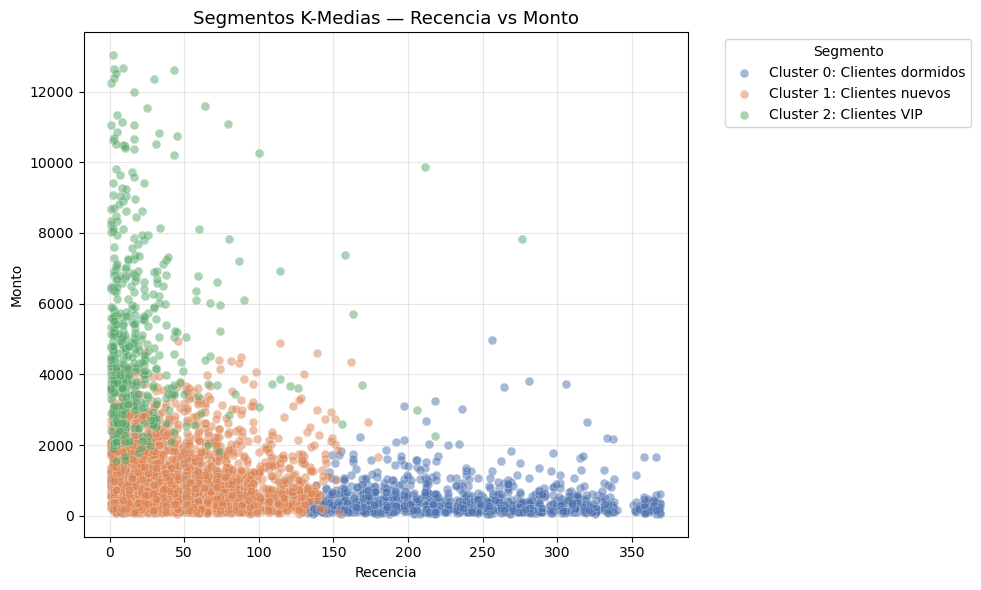

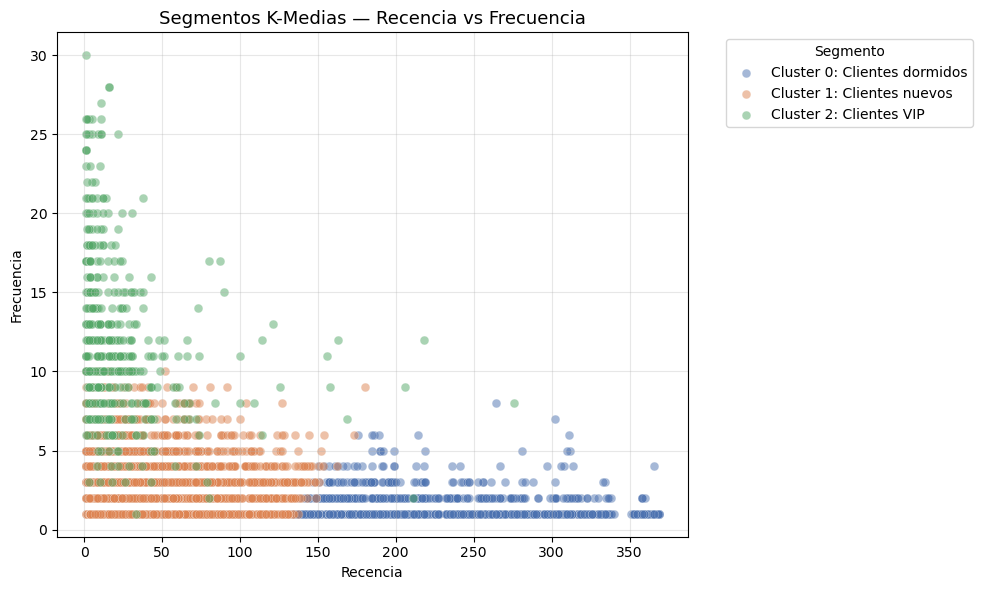

In [64]:
scatter_segmentos(rfm_final, 'recencia', 'monto',
                  etiquetas_negocio,
                  'Segmentos K-Medias — Recencia vs Monto')

scatter_segmentos(rfm_final, 'recencia', 'frecuencia',
                  etiquetas_negocio,
                  'Segmentos K-Medias — Recencia vs Frecuencia')

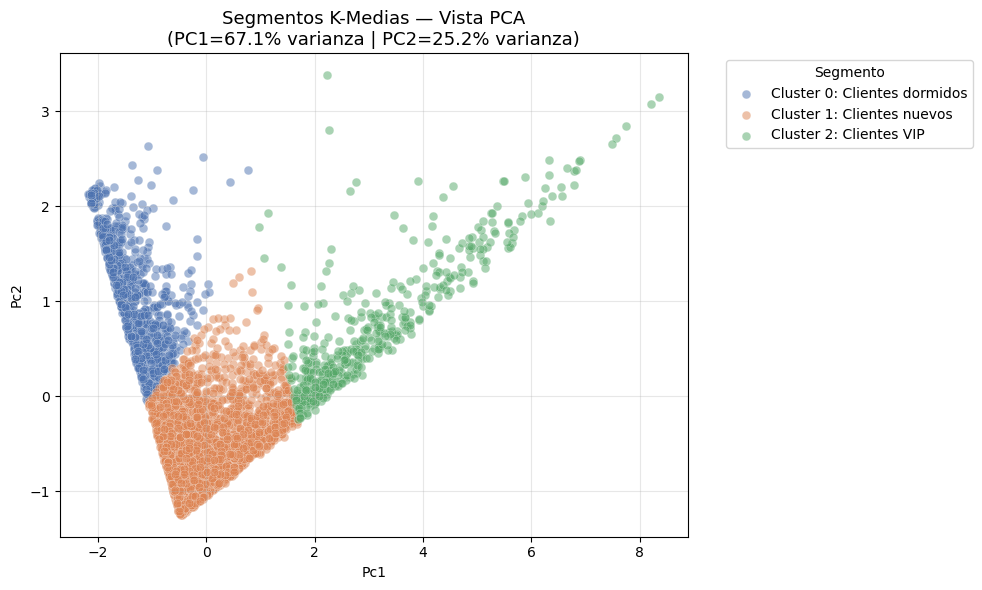

In [65]:
# Vista con PCA (mismas 3 variables comprimidas a 2 dimensiones)
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(X)
varianza  = pca.explained_variance_ratio_

rfm_pca = pd.DataFrame(coords_2d, columns=['PC1', 'PC2'], index=rfm_final.index)
rfm_pca['cluster'] = etiquetas

scatter_segmentos(
    rfm_pca, 'PC1', 'PC2',
    etiquetas_negocio,
    f'Segmentos K-Medias — Vista PCA\n'
    f'(PC1={varianza[0]*100:.1f}% varianza | PC2={varianza[1]*100:.1f}% varianza)'
)

### Gráfica de barras: perfil promedio por segmento

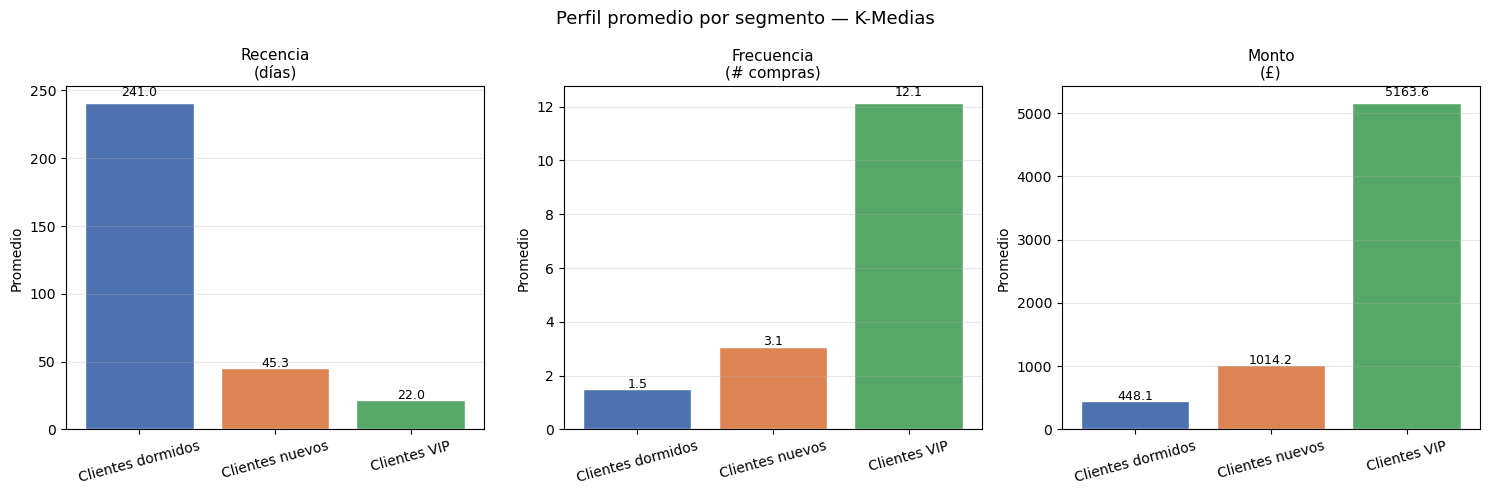

In [66]:
variables_rfm  = ['recencia', 'frecuencia', 'monto']
etiquetas_rfm  = ['Recencia\n(días)', 'Frecuencia\n(# compras)', 'Monto\n(£)']
colores_barra  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perfil promedio por segmento — K-Medias', fontsize=13)

nombres_clusters = [etiquetas_negocio[c] for c in sorted(rfm_final['cluster'].unique())]

for i, (var, etq) in enumerate(zip(variables_rfm, etiquetas_rfm)):
    promedios = [rfm_final[rfm_final['cluster'] == c][var].mean()
                 for c in sorted(rfm_final['cluster'].unique())]

    barras = axes[i].bar(nombres_clusters, promedios,
                         color=colores_barra[:len(promedios)], edgecolor='white')
    axes[i].set_title(etq, fontsize=11)
    axes[i].set_ylabel('Promedio')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)

    for barra, v in zip(barras, promedios):
        axes[i].text(barra.get_x() + barra.get_width() / 2,
                     v * 1.02, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### Radar chart (gráfica de araña)
Normalizamos los promedios al rango [0,1] para que todas las variables sean comparables.

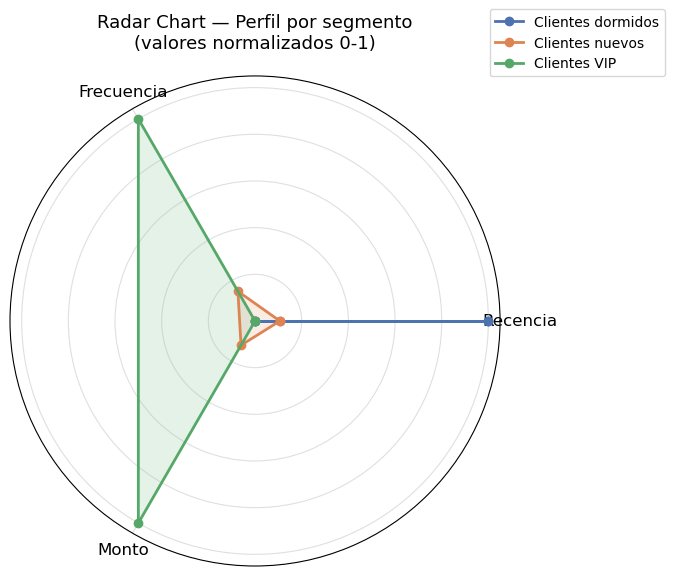

In [67]:
def graficar_radar(perfil_df, etiquetas_dict, variables, etiquetas_var):
    """
    Dibuja un radar chart con el perfil normalizado de cada segmento.
    Cada eje representa una variable RFM.
    """
    # Normalizamos los promedios al rango [0, 1]
    perfil_norm = perfil_df[variables].copy()
    for col in variables:
        rango = perfil_norm[col].max() - perfil_norm[col].min()
        perfil_norm[col] = (perfil_norm[col] - perfil_norm[col].min()) / rango if rango > 0 else 0

    num_vars = len(variables)
    # Ángulos para cada eje (distribuidos en círculo)
    angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angulos += angulos[:1]  # cerramos el polígono

    colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

    for i, cluster_id in enumerate(sorted(etiquetas_dict.keys())):
        valores = perfil_norm.loc[cluster_id, variables].tolist()
        valores += valores[:1]  # cerramos el polígono

        ax.plot(angulos, valores, 'o-', linewidth=2,
                color=colores[i], label=f'{etiquetas_dict[cluster_id]}')
        ax.fill(angulos, valores, alpha=0.15, color=colores[i])

    # Etiquetas de cada eje
    etq_completas = etiquetas_var + etiquetas_var[:1]
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(etiquetas_var, fontsize=12)
    ax.set_yticklabels([])
    ax.set_title('Radar Chart — Perfil por segmento\n(valores normalizados 0-1)', fontsize=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

graficar_radar(
    perfil,
    etiquetas_negocio,
    variables=['recencia', 'frecuencia', 'monto'],
    etiquetas_var=['Recencia', 'Frecuencia', 'Monto']
)

---
## Comparación con el Clustering Jerárquico

| Aspecto | Jerárquico (Ward) | K-Medias |
|---------|-------------------|----------|
| Clientes analizados | Muestra de 300 | Dataset completo (~4,300) |
| K elegido | 3 (por el dendrograma) | 3 (confirmado por codo + silueta) |
| Eficiencia | Lento — O(n³) | Rápido — O(nKdI) |
| Necesita K a priori | No | Sí |
| Forma de clusters asumida | Flexible | Esférica |
| Resultado interpretable | Sí (dendrograma) | Sí (centroides) |

In [68]:
# Cargamos los resultados jerárquicos para comparar perfiles
rfm_jer = pd.read_csv('rfm_jerarquico.csv', index_col=0)
perfil_jer = rfm_jer.groupby('cluster')[['recencia', 'frecuencia', 'monto']].mean().round(2)

print('=== Perfil promedio — Clustering Jerárquico (muestra de 300) ===')
print(perfil_jer)

print('\n=== Perfil promedio — K-Medias (dataset completo) ===')
print(perfil)

print('\nAmbos métodos coinciden en identificar 3 segmentos con perfiles similares.')
print('  K-Medias es más confiable aquí porque usa todos los clientes, no solo una muestra.')

=== Perfil promedio — Clustering Jerárquico (muestra de 300) ===
         recencia  frecuencia    monto
cluster                               
1          265.14        1.46   529.09
2           23.36       13.07  6559.67
3           48.12        3.30  1159.00

=== Perfil promedio — K-Medias (dataset completo) ===
         recencia  frecuencia    monto
cluster                               
0          240.97        1.51   448.13
1           45.32        3.07  1014.23
2           21.98       12.15  5163.57

Ambos métodos coinciden en identificar 3 segmentos con perfiles similares.
  K-Medias es más confiable aquí porque usa todos los clientes, no solo una muestra.


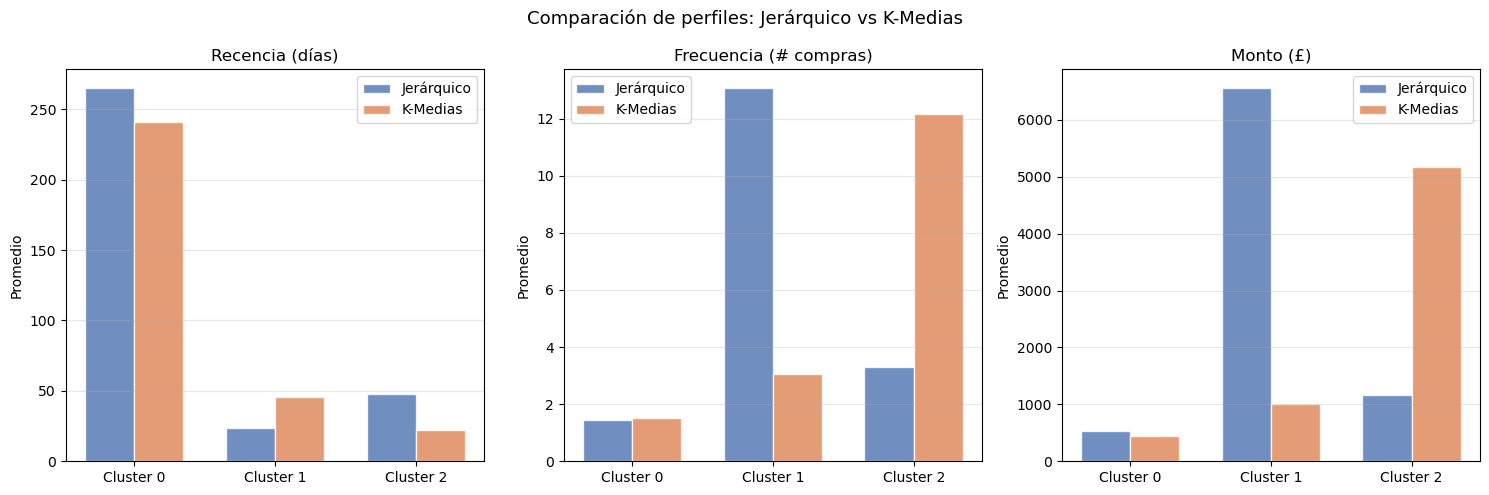

In [69]:
# Comparamos visualmente los perfiles de ambos métodos en un gráfico
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparación de perfiles: Jerárquico vs K-Medias', fontsize=13)

variables_rfm = ['recencia', 'frecuencia', 'monto']
etiquetas_rfm = ['Recencia (días)', 'Frecuencia (# compras)', 'Monto (£)']

for i, (var, etq) in enumerate(zip(variables_rfm, etiquetas_rfm)):
    x = np.arange(K_OPTIMO)
    ancho = 0.35

    vals_jer   = perfil_jer[var].values
    vals_kmeans = perfil[var].values

    axes[i].bar(x - ancho/2, vals_jer,    ancho, label='Jerárquico',
                color='#4C72B0', alpha=0.8, edgecolor='white')
    axes[i].bar(x + ancho/2, vals_kmeans, ancho, label='K-Medias',
                color='#DD8452', alpha=0.8, edgecolor='white')

    axes[i].set_title(etq)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([f'Cluster {c}' for c in sorted(rfm_final['cluster'].unique())])
    axes[i].set_ylabel('Promedio')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
# Guardamos los resultados
rfm_final.to_csv('rfm_segmentado.csv', index=True)

print(f'\nResumen de segmentos finales:')
resumen = rfm_final.groupby(['cluster', 'segmento']).size().reset_index(name='clientes')
resumen['pct'] = (resumen['clientes'] / resumen['clientes'].sum() * 100).round(1)
print(resumen.to_string(index=False))


Resumen de segmentos finales:
 cluster          segmento  clientes  pct
       0 Clientes dormidos      1024 24.6
       1   Clientes nuevos      2696 64.7
       2      Clientes VIP       449 10.8


---

## Etapa 4: Clasificación de nuevos clientes con K-NN

En las etapas anteriores **creamos** los segmentos con K-Medias (no supervisado).  
Ahora usamos esas etiquetas para **entrenar** un clasificador K-NN (supervisado).

El objetivo es poder asignar automáticamente a **nuevos clientes** al segmento correcto,
sin tener que volver a correr K-Medias.

K-NN funciona así: para clasificar un cliente nuevo, busca los K clientes más parecidos
en el conjunto de entrenamiento y le asigna el segmento que tenga la mayoría.

In [71]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, ConfusionMatrixDisplay)

In [72]:
# Cargamos los datos con las etiquetas de K-Medias (Etapa 3)
rfm_segmentado  = pd.read_csv('rfm_segmentado.csv',  index_col=0)
rfm_normalizado = pd.read_csv('rfm_normalizado.csv', index_col=0)

# Nos aseguramos de usar solo los clientes que coinciden en ambos archivos
idx_comun = rfm_segmentado.index.intersection(rfm_normalizado.index)
rfm_segmentado  = rfm_segmentado.loc[idx_comun]
rfm_normalizado = rfm_normalizado.loc[idx_comun]

print(f'Clientes disponibles: {len(rfm_segmentado):,}')
print('\nDistribución de segmentos:')
print(rfm_segmentado['segmento'].value_counts())

Clientes disponibles: 4,169

Distribución de segmentos:
segmento
Clientes nuevos      2696
Clientes dormidos    1024
Clientes VIP          449
Name: count, dtype: int64


In [73]:
# X = las variables RFM normalizadas (ya las normalizamos en la Etapa 1)
# y = la etiqueta de segmento que creó K-Medias (numérica: 0, 1, 2...)
X = rfm_normalizado.values
y = rfm_segmentado['cluster'].values

# Guardamos el mapa cluster - nombre de negocio para usarlo al predecir
mapa_segmento = rfm_segmentado.set_index('cluster')['segmento'].to_dict()
# Tomamos solo un nombre por cluster (puede haber duplicados)
mapa_segmento = {k: v for k, v in sorted(
    {row['cluster']: row['segmento'] for _, row in rfm_segmentado.iterrows()}.items()
)}

print(f'Variables de entrada (X): {X.shape}')
print(f'Variable objetivo (y)   : {y.shape}')
print(f'Clases únicas           : {sorted(np.unique(y))}')
print(f'Mapa de segmentos       : {mapa_segmento}')

Variables de entrada (X): (4169, 3)
Variable objetivo (y)   : (4169,)
Clases únicas           : [np.int64(0), np.int64(1), np.int64(2)]
Mapa de segmentos       : {0: 'Clientes dormidos', 1: 'Clientes nuevos', 2: 'Clientes VIP'}


In [74]:
# Dividimos en 80% entrenamiento y 20% prueba
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Conjunto de entrenamiento: {len(X_entrena):,} clientes (80%)')
print(f'Conjunto de prueba       : {len(X_prueba):,} clientes (20%)')

# Distribución de clases en ambos conjuntos
print('\nDistribución en entrenamiento:')
for c in sorted(np.unique(y)):
    n = (y_entrena == c).sum()
    print(f'  Cluster {c} ({mapa_segmento.get(c, "")}): {n} ({n/len(y_entrena)*100:.1f}%)')

print('\nDistribución en prueba:')
for c in sorted(np.unique(y)):
    n = (y_prueba == c).sum()
    print(f'  Cluster {c} ({mapa_segmento.get(c, "")}): {n} ({n/len(y_prueba)*100:.1f}%)')

Conjunto de entrenamiento: 3,335 clientes (80%)
Conjunto de prueba       : 834 clientes (20%)

Distribución en entrenamiento:
  Cluster 0 (Clientes dormidos): 819 (24.6%)
  Cluster 1 (Clientes nuevos): 2157 (64.7%)
  Cluster 2 (Clientes VIP): 359 (10.8%)

Distribución en prueba:
  Cluster 0 (Clientes dormidos): 205 (24.6%)
  Cluster 1 (Clientes nuevos): 539 (64.6%)
  Cluster 2 (Clientes VIP): 90 (10.8%)


---
## Seleccionar el mejor K con validación cruzada

Vamos a probar valores de K (número de vecinos) del 1 al 19 (solo impares, para evitar empates).  
Para cada K probamos dos variantes:
- **uniform**: todos los vecinos valen lo mismo al votar
- **distance**: los vecinos más cercanos pesan más

Usamos validación cruzada de 5 particiones (`cv=5`) para no depender de una sola división.

In [75]:
def evaluar_vecinos(X_train, y_train, rango_k, ponderacion):
    """
    Para cada K en rango_k, entrena K-NN con validación cruzada de 5 particiones
    y devuelve la lista de accuracy promedio.
    """
    scores = []
    for k in rango_k:
        modelo = KNeighborsClassifier(
            n_neighbors=k,
            weights=ponderacion,
            metric='euclidean'
        )
        # cross_val_score divide el entrenamiento en 5, entrena en 4 y evalúa en 1
        cv_scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')
        scores.append(cv_scores.mean())
    return scores

# Solo K impares
rango_k = list(range(1, 20, 2))  # [1, 3, 5, 7, ..., 19]
scores_uniform  = evaluar_vecinos(X_entrena, y_entrena, rango_k, 'uniform')
scores_distance = evaluar_vecinos(X_entrena, y_entrena, rango_k, 'distance')

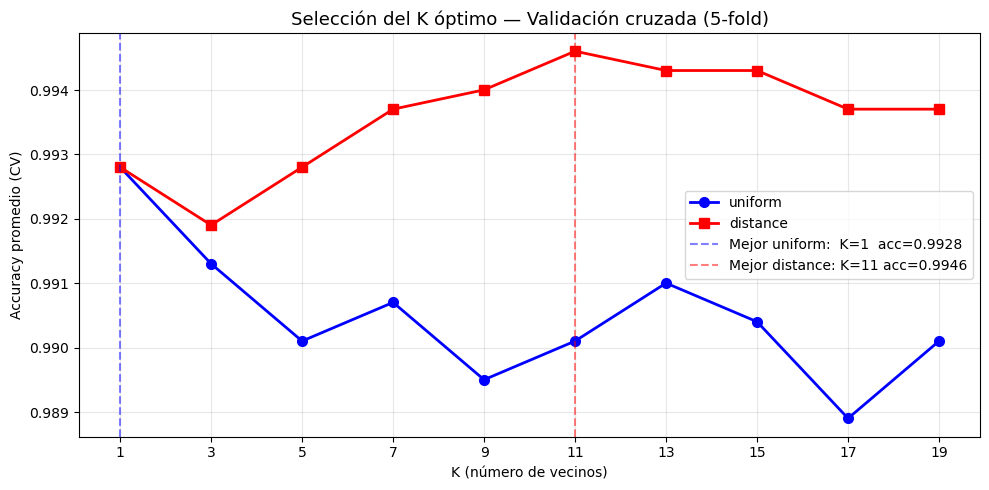

Mejor configuración:
  uniform  - K=1,  accuracy CV = 0.9928
  distance - K=11, accuracy CV = 0.9946


In [76]:
# Graficamos accuracy vs K para ambas ponderaciones
plt.figure(figsize=(10, 5))
plt.plot(rango_k, scores_uniform,  'bo-', linewidth=2, markersize=7, label='uniform')
plt.plot(rango_k, scores_distance, 'rs-', linewidth=2, markersize=7, label='distance')

# Marcamos el mejor K de cada variante
mejor_k_uniform  = rango_k[scores_uniform.index(max(scores_uniform))]
mejor_k_distance = rango_k[scores_distance.index(max(scores_distance))]

plt.axvline(mejor_k_uniform,  color='blue',  linestyle='--', alpha=0.5,
            label=f'Mejor uniform:  K={mejor_k_uniform}  acc={max(scores_uniform):.4f}')
plt.axvline(mejor_k_distance, color='red',   linestyle='--', alpha=0.5,
            label=f'Mejor distance: K={mejor_k_distance} acc={max(scores_distance):.4f}')

plt.title('Selección del K óptimo — Validación cruzada (5-fold)', fontsize=13)
plt.xlabel('K (número de vecinos)')
plt.ylabel('Accuracy promedio (CV)')
plt.xticks(rango_k)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mejor configuración:')
print(f'  uniform  - K={mejor_k_uniform},  accuracy CV = {max(scores_uniform):.4f}')
print(f'  distance - K={mejor_k_distance}, accuracy CV = {max(scores_distance):.4f}')

In [77]:
# Elegimos la mejor combinación K + ponderación
if max(scores_distance) >= max(scores_uniform):
    K_FINAL = mejor_k_distance
    PONDERACION = 'distance'
else:
    K_FINAL = mejor_k_uniform
    PONDERACION = 'uniform'

print(f'Configuración seleccionada:')
print(f'  K          = {K_FINAL}')
print(f'  Ponderación = {PONDERACION}')
print(f'  Accuracy CV = {max(scores_distance if PONDERACION=="distance" else scores_uniform):.4f}')

Configuración seleccionada:
  K          = 11
  Ponderación = distance
  Accuracy CV = 0.9946


## Entrenar el modelo final y evaluar en el conjunto de prueba

In [78]:
# Entrenamos el modelo final con los parámetros elegidos
knn = KNeighborsClassifier(
    n_neighbors=K_FINAL,
    weights=PONDERACION,
    metric='euclidean'
)
knn.fit(X_entrena, y_entrena)

# Predecimos en el conjunto de PRUEBA (datos que el modelo nunca vio)
y_pred = knn.predict(X_prueba)

acc = accuracy_score(y_prueba, y_pred)
print(f'Accuracy en conjunto de prueba: {acc:.4f} ({acc*100:.2f}%)')

Accuracy en conjunto de prueba: 0.9940 (99.40%)


### Matriz de confusión

La matriz de confusión muestra cuántos clientes fueron clasificados correctamente (diagonal)
y cuántos fueron confundidos con otro segmento (fuera de la diagonal).

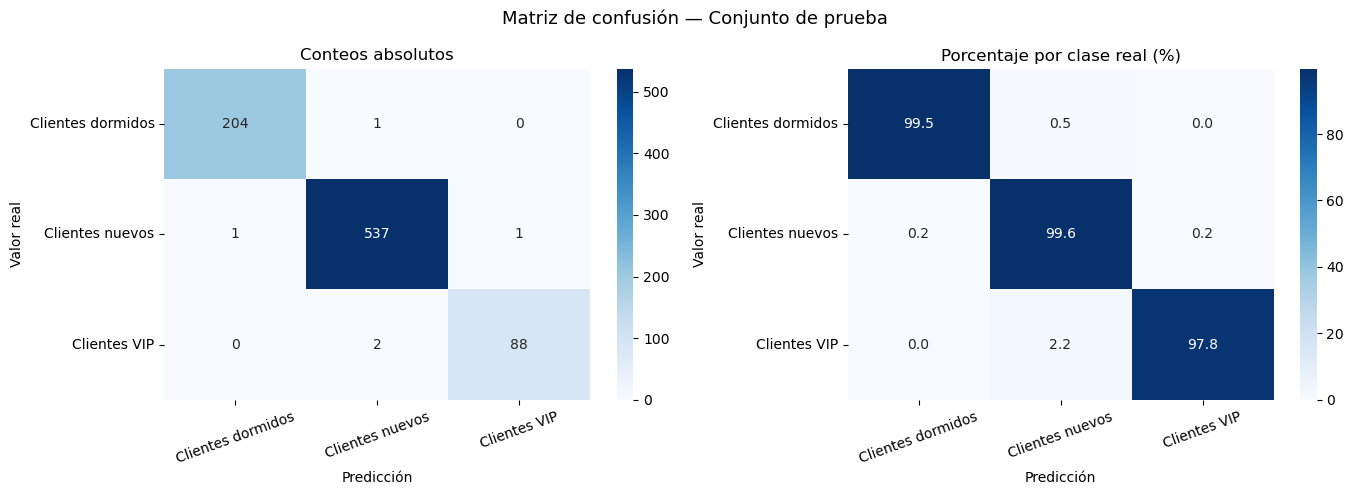

In [79]:
# Etiquetas legibles para los ejes de la matriz
nombres_clases = [mapa_segmento.get(c, f'Cluster {c}') for c in sorted(np.unique(y))]

# Calculamos la matriz
cm = confusion_matrix(y_prueba, y_pred, labels=sorted(np.unique(y)))

# Graficamos como un heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matriz de confusión — Conjunto de prueba', fontsize=13)

# Izquierda: conteos absolutos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax1)
ax1.set_title('Conteos absolutos')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Valor real')
ax1.tick_params(axis='x', rotation=20)
ax1.tick_params(axis='y', rotation=0)

# Derecha: porcentajes por fila (qué % de cada clase fue bien clasificado)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases, ax=ax2)
ax2.set_title('Porcentaje por clase real (%)')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Valor real')
ax2.tick_params(axis='x', rotation=20)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### Reporte de métricas por clase

| Métrica | ¿Qué mide? |
|---------|------------|
| **Accuracy** | % de predicciones correctas en total |
| **Precision** | De los que predije como clase X, ¿cuántos sí eran X? |
| **Recall** | De los que realmente son clase X, ¿cuántos detecté? |
| **F1-score** | Promedio balanceado entre Precision y Recall |

In [80]:
# Reporte completo de métricas
reporte = classification_report(
    y_prueba, y_pred,
    target_names=nombres_clases,
    digits=4
)
print('=== Reporte de clasificación ===')
print(reporte)

=== Reporte de clasificación ===
                   precision    recall  f1-score   support

Clientes dormidos     0.9951    0.9951    0.9951       205
  Clientes nuevos     0.9944    0.9963    0.9954       539
     Clientes VIP     0.9888    0.9778    0.9832        90

         accuracy                         0.9940       834
        macro avg     0.9928    0.9897    0.9912       834
     weighted avg     0.9940    0.9940    0.9940       834



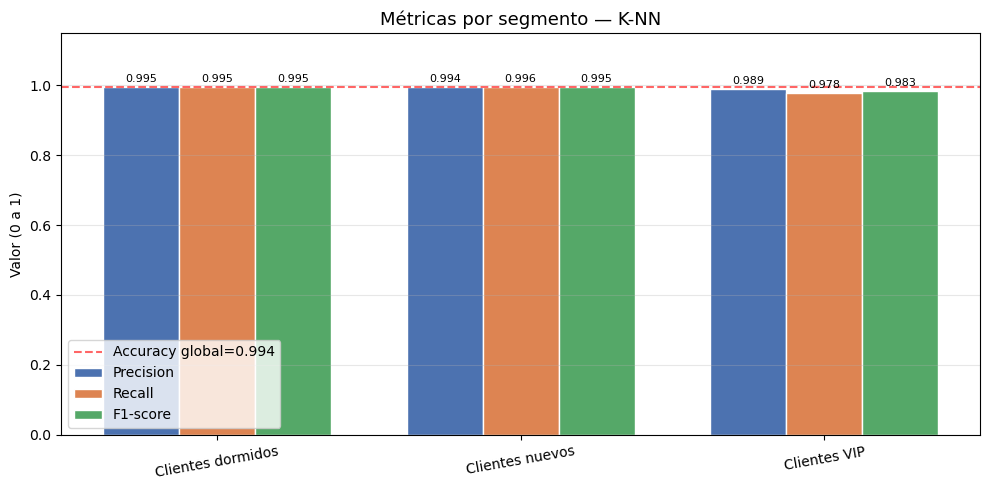

In [81]:
# Graficamos precision, recall y F1 por clase para visualizarlo mejor
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(
    y_prueba, y_pred, labels=sorted(np.unique(y))
)

x       = np.arange(len(nombres_clases))
ancho   = 0.25
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - ancho, precision, ancho, label='Precision', color=colores[0], edgecolor='white')
ax.bar(x, recall, ancho, label='Recall', color=colores[1], edgecolor='white')
ax.bar(x + ancho, f1, ancho, label='F1-score', color=colores[2], edgecolor='white')

ax.set_title('Métricas por segmento — K-NN', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(nombres_clases, rotation=10)
ax.set_ylabel('Valor (0 a 1)')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(acc, color='red', linestyle='--', alpha=0.6, label=f'Accuracy global={acc:.3f}')
ax.legend()

# Valor encima de cada barra
for barras in [ax.containers[0], ax.containers[1], ax.containers[2]]:
    ax.bar_label(barras, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

---
## Predicción con nuevos clientes

Simulamos 3 clientes nuevos con perfiles distintos para demostrar que el modelo funciona.  
**Importante:** Los datos del cliente nuevo hay que normalizarlos **con el mismo scaler** que usamos en la Etapa 1.  
Por eso volvemos a ajustar el scaler con los datos de entrenamiento.

In [82]:
# Recreamos el scaler ajustado con los datos originales (sin normalizar)
# para poder normalizar los clientes nuevos de la misma forma
rfm_limpio = pd.read_csv('rfm_limpio.csv', index_col=0)
rfm_limpio = rfm_limpio.loc[rfm_segmentado.index]  # mismos clientes

scaler = StandardScaler()
scaler.fit(rfm_limpio[['recencia', 'frecuencia', 'monto']])

print('Scaler ajustado')
print(f'  Medias usadas: recencia={scaler.mean_[0]:.1f}, frecuencia={scaler.mean_[1]:.1f}, monto={scaler.mean_[2]:.1f}')
print(f'  Std usadas:    recencia={scaler.scale_[0]:.1f}, frecuencia={scaler.scale_[1]:.1f}, monto={scaler.scale_[2]:.1f}')

Scaler ajustado
  Medias usadas: recencia=90.9, frecuencia=3.7, monto=1322.1
  Std usadas:    recencia=96.6, frecuencia=3.8, monto=1732.8


In [83]:
def predecir_cliente(recencia, frecuencia, monto, scaler, modelo, mapa):
    """
    Recibe los datos originales de un cliente nuevo (sin normalizar),
    los normaliza y predice su segmento.
    """
    # Creamos un DataFrame con los datos del cliente
    cliente = pd.DataFrame(
        [[recencia, frecuencia, monto]],
        columns=['recencia', 'frecuencia', 'monto']
    )
    # Normalizamos con el mismo scaler que se usó en entrenamiento
    cliente_norm = scaler.transform(cliente)

    # Predecimos el cluster
    cluster_pred = modelo.predict(cliente_norm)[0]

    # Obtenemos las probabilidades de cada clase (proporción de vecinos)
    probabilidades = modelo.predict_proba(cliente_norm)[0]
    clases = modelo.classes_

    return cluster_pred, mapa.get(cluster_pred, f'Cluster {cluster_pred}'), probabilidades, clases

In [84]:
# Definimos 3 clientes nuevos con perfiles distintos
clientes_nuevos = [
    {
        'nombre'    : 'Cliente A — Perfil activo y frecuente',
        'recencia'  : 10,    # compró hace 10 días (muy reciente)
        'frecuencia': 15,    # 15 compras históricas
        'monto'     : 3500   # £3,500 gastados
    },
    {
        'nombre'    : 'Cliente B — Perfil dormido',
        'recencia'  : 300,   # lleva 300 días sin comprar
        'frecuencia': 2,     # solo ha comprado 2 veces
        'monto'     : 150    # £150 gastados
    },
    {
        'nombre'    : 'Cliente C — Perfil en riesgo',
        'recencia'  : 180,   # 6 meses sin comprar
        'frecuencia': 10,    # compraba frecuente antes
        'monto'     : 2200   # gastó bastante en su momento
    }
]

In [85]:
# Predecimos el segmento de cada cliente nuevo
print('=== Predicciones para clientes nuevos ===\n')

resultados = []

for cliente in clientes_nuevos:
    cluster_id, segmento, probs, clases = predecir_cliente(
        recencia = cliente['recencia'],
        frecuencia = cliente['frecuencia'],
        monto = cliente['monto'],
        scaler = scaler,
        modelo = knn,
        mapa = mapa_segmento
    )

    print(f"{'─'*55}")
    print(f"  {cliente['nombre']}")
    print(f"  Datos     : recencia={cliente['recencia']} días, "
          f"frecuencia={cliente['frecuencia']}, monto=£{cliente['monto']}")
    print(f"  Segmento  : Cluster {cluster_id} - {segmento}")
    print(f"  Confianza  por clase:")
    for c, p in zip(clases, probs):
        print(f"    Cluster {c} ({mapa_segmento.get(c,'?')}): {p:.1%}")

    resultados.append({'nombre': cliente['nombre'], 'cluster': cluster_id,
                       'segmento': segmento, 'probs': probs, 'clases': clases})

print(f"{'─'*55}")

=== Predicciones para clientes nuevos ===

───────────────────────────────────────────────────────
  Cliente A — Perfil activo y frecuente
  Datos     : recencia=10 días, frecuencia=15, monto=£3500
  Segmento  : Cluster 2 - Clientes VIP
  Confianza  por clase:
    Cluster 0 (Clientes dormidos): 0.0%
    Cluster 1 (Clientes nuevos): 0.0%
    Cluster 2 (Clientes VIP): 100.0%
───────────────────────────────────────────────────────
  Cliente B — Perfil dormido
  Datos     : recencia=300 días, frecuencia=2, monto=£150
  Segmento  : Cluster 0 - Clientes dormidos
  Confianza  por clase:
    Cluster 0 (Clientes dormidos): 100.0%
    Cluster 1 (Clientes nuevos): 0.0%
    Cluster 2 (Clientes VIP): 0.0%
───────────────────────────────────────────────────────
  Cliente C — Perfil en riesgo
  Datos     : recencia=180 días, frecuencia=10, monto=£2200
  Segmento  : Cluster 1 - Clientes nuevos
  Confianza  por clase:
    Cluster 0 (Clientes dormidos): 6.4%
    Cluster 1 (Clientes nuevos): 54.6%
    Cl

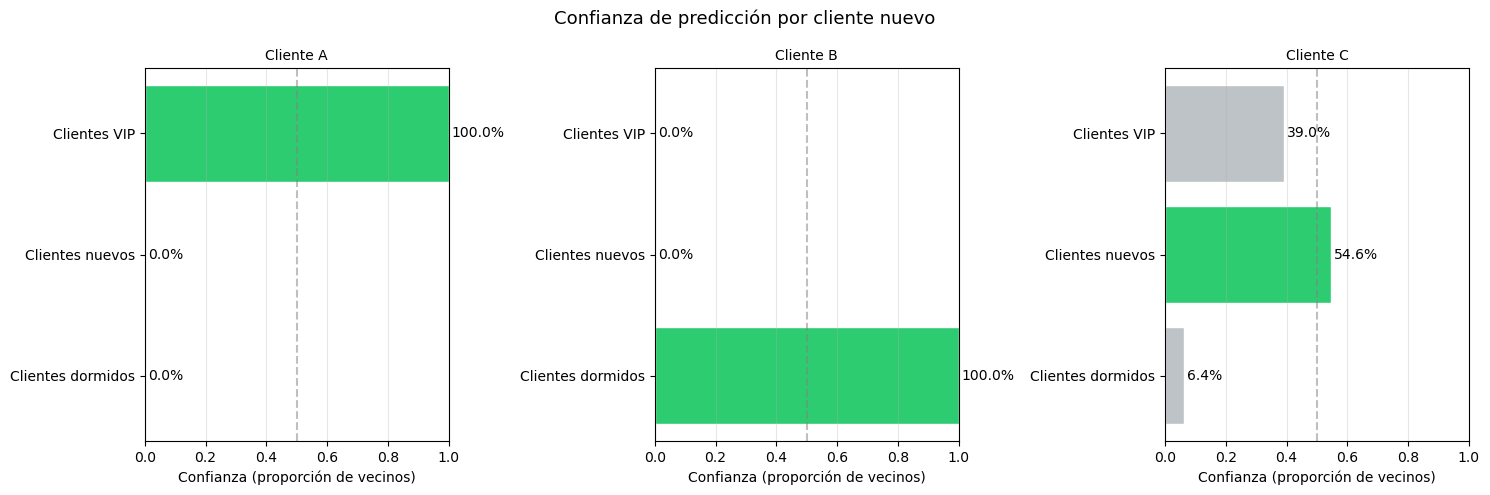

In [86]:
# Visualización: gráfica de barras de confianza para cada cliente nuevo
colores_cluster = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confianza de predicción por cliente nuevo', fontsize=13)

for i, res in enumerate(resultados):
    nombres_clases_pred = [mapa_segmento.get(c, f'Cluster {c}') for c in res['clases']]
    colores_barra = ['#2ecc71' if c == res['cluster'] else '#bdc3c7'
                     for c in res['clases']]

    axes[i].barh(nombres_clases_pred, res['probs'],
                 color=colores_barra, edgecolor='white')
    axes[i].set_xlim(0, 1)
    axes[i].set_title(res['nombre'].split('—')[0].strip(), fontsize=10)
    axes[i].set_xlabel('Confianza (proporción de vecinos)')
    axes[i].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[i].grid(axis='x', alpha=0.3)

    for j, v in enumerate(res['probs']):
        axes[i].text(v + 0.01, j, f'{v:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

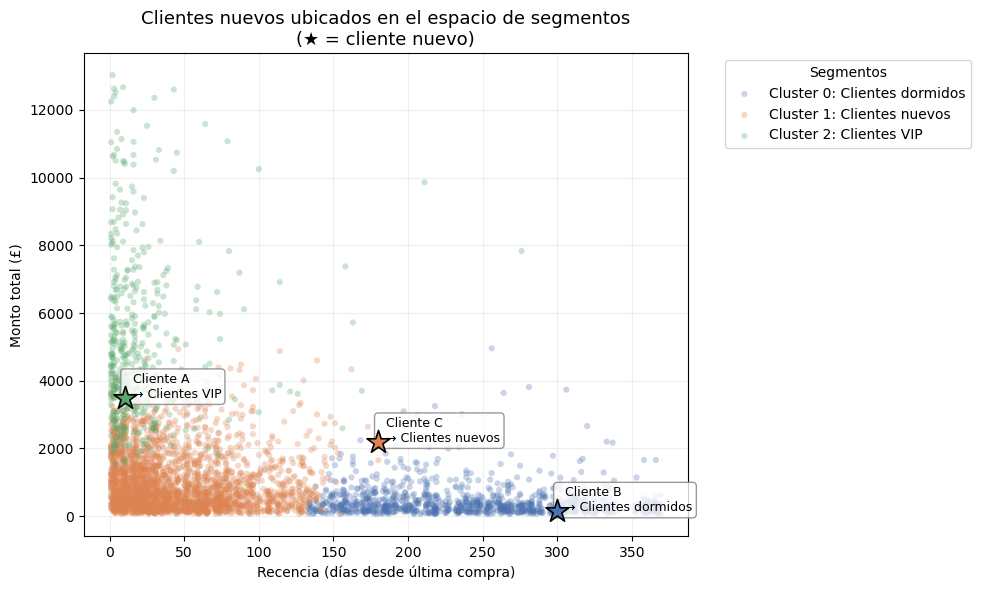

In [87]:
# Ubicamos a los 3 clientes nuevos dentro del scatter plot
# para ver visualmente si caen en la zona correcta
rfm_plot = rfm_limpio.copy()
rfm_plot['cluster'] = rfm_segmentado['cluster'].values

colores_seg = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
marcadores  = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(10, 6))

# Fondo: todos los clientes del dataset
for i, c in enumerate(sorted(rfm_plot['cluster'].unique())):
    mask = rfm_plot['cluster'] == c
    ax.scatter(rfm_plot.loc[mask, 'recencia'], rfm_plot.loc[mask, 'monto'],
               color=colores_seg[i], alpha=0.3, s=20, edgecolors='none',
               label=f'Cluster {c}: {mapa_segmento.get(c, "")}')

# Encima: los 3 clientes nuevos
iconos_nuevos = ['★', '★', '★']
for j, (cliente, res) in enumerate(zip(clientes_nuevos, resultados)):
    ax.scatter(cliente['recencia'], cliente['monto'],
               color=colores_seg[res['cluster'] % len(colores_seg)],
               s=300, marker='*', edgecolors='black', linewidth=1.2, zorder=5)
    ax.annotate(
        f"  Cliente {['A','B','C'][j]}\n  → {res['segmento']}",
        xy=(cliente['recencia'], cliente['monto']),
        fontsize=9, color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
    )

ax.set_title('Clientes nuevos ubicados en el espacio de segmentos\n(★ = cliente nuevo)', fontsize=13)
ax.set_xlabel('Recencia (días desde última compra)')
ax.set_ylabel('Monto total (£)')
ax.legend(title='Segmentos', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Observaciones

| Aspecto | Resultado |
|---------|----------|
| Variable objetivo | Etiquetas de K-Medias (Etapa 3) |
| División | 80% entrenamiento / 20% prueba (estratificada) |
| K seleccionado | Elegido por validación cruzada 5-fold |
| Ponderación | uniform vs distance — se elige la mejor |
| Accuracy prueba | Ver celda de evaluación arriba |
| Clientes nuevos | 3 simulados, clasificados e interpretados |

### ¿Por qué K-NN funciona bien aquí?

Los segmentos RFM tienen **fronteras geométricas bien definidas** en el espacio normalizado.  
K-NN es ideal para esto: busca los clientes más parecidos y vota, sin asumir ninguna forma matemática de los grupos.

### Limitación a tener en cuenta

K-NN **almacena todos los datos de entrenamiento** para hacer predicciones.  
Si la empresa crece mucho (millones de clientes), conviene reemplazarlo por un modelo más liviano como un árbol de decisión o regresión logística entrenado sobre las mismas etiquetas.

In [88]:
print('='*55)
print('   Resumen del proyecto integrador')
print('='*55)
print()
print('Etapa 1 — Preprocesamiento')
print(f'  Clientes limpios listos: {len(rfm_limpio):,}')
print()
print('Etapa 2 — Clustering Jerárquico (Ward)')
print(f'  Muestra analizada : 300 clientes')
print(f'  K sugerido        : 3')
print()
print('Etapa 3 — K-Medias')
print(f'  Clientes segmentados: {len(rfm_segmentado):,}')
print(f'  K final             : {len(mapa_segmento)}')
print('  Segmentos:')
for c, nombre in mapa_segmento.items():
    n = (rfm_segmentado['cluster'] == c).sum()
    print(f'    Cluster {c}: {nombre} ({n} clientes)')
print()
print('Etapa 4 — K-NN Clasificador')
print(f'  K vecinos   : {K_FINAL}')
print(f'  Ponderación : {PONDERACION}')
print(f'  Accuracy    : {acc:.4f} ({acc*100:.2f}%)')

   Resumen del proyecto integrador

Etapa 1 — Preprocesamiento
  Clientes limpios listos: 4,169

Etapa 2 — Clustering Jerárquico (Ward)
  Muestra analizada : 300 clientes
  K sugerido        : 3

Etapa 3 — K-Medias
  Clientes segmentados: 4,169
  K final             : 3
  Segmentos:
    Cluster 0: Clientes dormidos (1024 clientes)
    Cluster 1: Clientes nuevos (2696 clientes)
    Cluster 2: Clientes VIP (449 clientes)

Etapa 4 — K-NN Clasificador
  K vecinos   : 11
  Ponderación : distance
  Accuracy    : 0.9940 (99.40%)
